<hr>
<div>
<h2>Initialize Environment</h2>
<p>Initializes the shared imports, plotting style, file paths, constants, and helper functions used throughout the study. Each section then loads only the data and defines only the components it requires.</p>
</div>


In [1]:
# Standard Library
from pathlib import Path

# Numerical and Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Optimization
from scipy.optimize import minimize

# Scikit-Learn: Models
from sklearn.cluster import KMeans
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

# Scikit-Learn: Preprocessing and Calibration
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Scikit-Learn: Metrics
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    silhouette_score,
)

# Jupyter
from IPython.display import display


In [2]:
# Plotting Theme and Color Palette
SURFACE = '#ffffff'
INK = '#0b0b0b'
MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'
PALETTE = [ACCENT, '#17369b', '#6f8fe8', RED, MUTED, INK]

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.color': GRIDLINE,
    'grid.linewidth': 0.8,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})

# Shared Table Styles
TABLE_STYLES = [
    {
        'selector': 'caption',
        'props': [
            ('caption-side', 'top'),
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('text-align', 'left'),
            ('padding-bottom', '8px'),
        ],
    },
    {
        'selector': 'th',
        'props': [('text-align', 'left !important')],
    },
    {
        'selector': 'td',
        'props': [('text-align', 'left !important')],
    },
]

In [3]:
# Data Loading and Export Helpers
DATA = Path('data/synthetic')

def load(name):
    
    pq, csv = DATA / f'{name}.parquet', DATA / f'{name}.csv'
    if pq.exists():
        return pd.read_parquet(pq)
    
    if csv.exists():
        return pd.read_csv(csv)
    
    raise FileNotFoundError(
        f'{name} not found in {DATA.resolve()}. Run '
        'data/00_generate_and_validate_data.ipynb, then the earlier sections, first.')

    
def _parquet_available():
    
    for mod in ('pyarrow', 'fastparquet'):
        try:
            __import__(mod)
            return True
        
        except ImportError:
            continue
            
    print('pyarrow/fastparquet not found; writing CSV instead.')
    
    return False


FMT = 'parquet' if _parquet_available() else 'csv'

def save_tables(frames, dest = DATA, with_cols = False):
    
    dest = Path(dest)
    dest.mkdir(parents = True, exist_ok = True)
    
    names, rows, cols = [], [], []
    for name, df in frames.items():
        path = dest / f'{name}.{FMT}'
        df.to_parquet(path, index = False) if FMT == 'parquet' else df.to_csv(path, index = False)
        names.append(path.name)
        rows.append(len(df))
        cols.append(df.shape[1])
        
    data = {'rows': rows, 'cols': cols} if with_cols else {'rows': rows}
    
    return pd.DataFrame(data, index = names).rename_axis(None)


In [4]:
# Domain Constants and Data-Preparation Helpers
CLASSES = ['null', 'partial', 'full']
IDX = {c: i for i, c in enumerate(CLASSES)}
DAY_THRESH = 0.70
PRICE_FIRST, PRICE_ADDL = 10.0, 5.0


def reconstruct_label(df, day_thresh = DAY_THRESH):

    ratio = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower = 1)

    y = pd.Series('full', index = df.index, dtype = object)
    y[(ratio < day_thresh) | (lines < 0.999)] = 'partial'
    y[df['days_bought'] == 0] = 'null'

    return y


def build_features(df):

    out = pd.DataFrame(index = df.index)
    out['is_business'] = df['is_business'].astype(int)
    out['lines_on_account'] = df['lines_on_account']
    out['tenure_months'] = df['tenure_months']
    out['premium'] = (df['plan_tier'] == 'premium').astype(int)
    out['value_tier'] = (df['plan_tier'] == 'value').astype(int)
    
    for r in ['asia', 'caribbean', 'central_america', 'europe', 'mideast', 'oceania', 'south_america']:  # Basline: Africa
        out[f'region_{r}'] = (df['region'] == r).astype(int)

    out['month_of_year'] = df['month'] % 12
    out['macro_index'] = df['macro_index']

    return out


def prior_trip_count(df):

    hist = df[['account_id', 'month']].sort_values(['account_id', 'month'])
    cum = hist.groupby('account_id').cumcount()
    same = hist.groupby(['account_id', 'month']).cumcount()

    return (cum - same).reindex(df.index).fillna(0).astype(int)


def load_trips(with_macro = True):

    t = load('trips').merge(load('accounts'), on = 'account_id', how = 'left')

    if with_macro:
        t = t.merge(load('macro')[['month', 'macro_index']], on = 'month', how = 'left')

    return t


In [5]:
# Probability and Price-Shift Helpers
_SORTED_CLASSES = sorted(CLASSES)
_PERM = [CLASSES.index(c) for c in _SORTED_CLASSES]


def LL(y_true, P):
    
    return log_loss(y_true, P[:, _PERM], labels = _SORTED_CLASSES)


def softmax(eta):
    
    e = np.exp(eta - eta.max(axis = 1, keepdims = True))
    
    return e / e.sum(axis=1, keepdims = True)


def logp(p):
    
    return np.log(np.clip(p, 1e-9, 1.0))


def price_shift_logodds(sweep, mult, ref = 1.0):
    
    idx = sweep.index.to_numpy()
    tgt = sweep.iloc[np.argmin(np.abs(idx - mult))][CLASSES].to_numpy()
    base = sweep.iloc[np.argmin(np.abs(idx - ref))][CLASSES].to_numpy()
    
    return logp(tgt) - logp(base)


def apply_price_shift(P0, shift, response_scale = 1.0):
    
    return softmax(logp(P0) + response_scale * shift)


<hr style="border: none; border-top: 2px solid #4A4A4A;">
<div>
<h1>03 · The 12-Month Simulation</h1>
<p><strong>Purpose:</strong> The State and Magnitude Models estimate what happens on an individual trip. The simulation translates those trip-level relationships into a distribution of 12-month roaming revenue at each candidate price. It answers how much revenue could result and how widely that result could vary under the modeled sources of uncertainty.</p>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Why simulation is required</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>A single expected-value calculation summarizes the center of the modeled outcome but does not describe its potential variation.</li>
<li>Reporting only a point estimate would conceal the effects of shared economic and market conditions.</li>
<li>The simulation repeatedly draws the modeled inputs and trip outcomes, producing a revenue distribution for each candidate price.</li>
</ul></li>
</ol>
<p><strong>Sources of uncertainty</strong></p>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Source</th>
<th style="text-align: left;">Dependence structure</th>
<th style="text-align: left;">Why it matters</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Macroeconomic path</td>
<td style="text-align: left; vertical-align: top;">Shared across the customer book and correlated over time</td>
<td style="text-align: left; vertical-align: top;">Changes aggregate international-travel volume</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Market-share change</td>
<td style="text-align: left; vertical-align: top;">Shared across the customer book</td>
<td style="text-align: left; vertical-align: top;">Changes the share of international travel retained by the company</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Trip and coverage-state realization</td>
<td style="text-align: left; vertical-align: top;">Independent by trip, conditional on the shared inputs</td>
<td style="text-align: left; vertical-align: top;">Determines which projected trips occur and which coverage state each trip enters</td>
</tr>
</tbody>
</table>
<ol start="2" style="margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Shared shocks are essential to the revenue distribution</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Macroeconomic and market-share draws are made once per iteration and applied across the customer book.</li>
<li>This allows favorable or unfavorable conditions to affect many accounts simultaneously.</li>
<li>Drawing every outcome independently would allow positive and negative results to cancel excessively, understating aggregate uncertainty.</li>
<li>Trip occurrence and coverage state are drawn independently after conditioning on the shared inputs.</li>
<li>Multiple trips belonging to the same account do not receive an additional account-level behavioral correlation. This is a simplifying assumption of the simulation.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation of the simulated distribution</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The resulting distribution measures variability under the fitted models and specified simulation assumptions.</li>
<li>It is not a complete forecast interval for every way the revenue estimate could be wrong.</li>
<li>Model coefficients, calibration mappings, regional-response sensitivities, and synthetic data-generating assumptions remain fixed within each scenario.</li>
<li>Selected forms of model risk are examined through separate sensitivity cases rather than stochastic parameter draws.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Two model-risk sensitivities reduce projected revenue at higher prices</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The State Model’s regional holdout motivates a stronger price-response sensitivity.</li>
<li>The Magnitude Model’s partial-label diagnostic motivates a stronger day-reduction sensitivity.</li>
<li>Both sensitivities reduce modeled revenue at higher prices, but neither is treated as a correction to known truth or a statistical bound.</li>
</ul>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Case</th>
<th style="text-align: left;">Price response</th>
<th style="text-align: left;">Day-reduction depth</th>
<th style="text-align: left;">Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Fitted case</td>
<td style="text-align: left; vertical-align: top;"><code>response_scale = 1.00</code></td>
<td style="text-align: left; vertical-align: top;"><code>day_depth_scale = 1.00</code></td>
<td style="text-align: left; vertical-align: top;">Uses the fitted State and Magnitude Model responses</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Combined stronger-response sensitivity</td>
<td style="text-align: left; vertical-align: top;">Regional response sensitivity</td>
<td style="text-align: left; vertical-align: top;">Stronger day-depth sensitivity</td>
<td style="text-align: left; vertical-align: top;">Tests the recommendation under stronger movement away from coverage and deeper day reductions</td>
</tr>
</tbody>
</table>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Every candidate price is evaluated under both cases.</li>
<li>The recommendation is compared across the two cases and anchored to the combined stronger-response sensitivity.</li>
<li>This sensitivity is intentionally more adverse for higher-price revenue, but it is not presented as a guaranteed conservative outcome.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Scope</strong>
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The simulation estimates roaming-pass revenue over the next 12 months.</li>
<li>Wireless churn (customers leaving the carrier) is outside the scope of this study and is not modeled.</li>
<li>The simulation does not estimate customer-lifetime-value effects, broader wireless-service revenue, or other company-level consequences of a price change.</li>
<li>Final results should therefore be interpreted as roaming-revenue estimates rather than total financial impact.</li>
</ul></li>
</ol>
</div>


In [28]:
# Load Simulation Inputs
trips = load_trips(with_macro = False)
macro = load('macro')
scored = load('scored_trips')
prob_scen = load('sim_prob_scenarios')
rev_scen = load('sim_revenue_scenarios')

model_meta = (
    load('model_meta')
    .set_index('key')['value']
)

mag_meta = (
    load('magnitude_meta')
    .set_index('key')['value']
)

probability_grid = np.sort(
    prob_scen[
        'price_multiplier'
    ].round(4).unique()
)

revenue_grid = np.sort(
    rev_scen[
        'price_multiplier'
    ].round(4).unique()
)

if not np.array_equal(
    probability_grid,
    revenue_grid,
):
    raise ValueError(
        'probability and revenue scenario grids do not match'
    )

GRID = revenue_grid

RESPONSE_RATIO = float(
    model_meta.get(
        'response_ratio',
        1.0,
    )
)

DEPTH_BIAS = float(
    mag_meta.get(
        'depth_bias',
        1.0,
    )
)

if not np.isfinite(RESPONSE_RATIO):
    raise ValueError(
        'response ratio must be finite'
    )

if not np.isfinite(DEPTH_BIAS):
    raise ValueError(
        'depth-bias multiplier must be finite'
    )

LOWER_RESPONSE_RATIO = 2.0 - RESPONSE_RATIO
assert LOWER_RESPONSE_RATIO > 0, 'lower response scale must stay positive'

LOWER_DEPTH_BIAS = 2.0 - DEPTH_BIAS
assert LOWER_DEPTH_BIAS > 0, 'lower depth scale must stay positive'

input_summary = pd.DataFrame({
    'Input': [
        'Candidate price range',
        'Candidate price levels',
        'Response sensitivity',
        'Depth sensitivity',
        'Trip records',
        'Probability-scenario rows',
        'Revenue-scenario rows',
    ],
    'Value': [
        f'{GRID[0]:.3f}–{GRID[-1]:.3f}',
        f'{len(GRID):,}',
        f'{RESPONSE_RATIO:.2f}×',
        f'{DEPTH_BIAS:.2f}×',
        f'{len(trips):,}',
        f'{len(prob_scen):,}',
        f'{len(rev_scen):,}',
    ],
    'Source': [
        'Aligned scenario grids',
        'Aligned scenario grids',
        'State Model',
        'Magnitude Model',
        'Trip data',
        'State Model export',
        'Magnitude Model export',
    ],
})

display(
    input_summary.style
    .hide(axis = 'index')
    .set_caption('Revenue-Simulation Inputs')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)


Input,Value,Source
Candidate price range,0.900–1.200,Aligned scenario grids
Candidate price levels,13,Aligned scenario grids
Response sensitivity,1.76×,State Model
Depth sensitivity,1.04×,Magnitude Model
Trip records,"94,579",Trip data
Probability-scenario rows,"2,047,500",State Model export
Revenue-scenario rows,"2,047,500",Magnitude Model export


<div>
<h2>1 · Building the Forward Year</h2>
<p><strong>Purpose:</strong> Constructs a forward 12-month panel of candidate trip profiles from the most recent historical year. Each simulation iteration determines which of those profiles occur under the drawn macroeconomic, market-share, and seasonal conditions.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Historical Trip Templates.</strong> Trips from the most recent 12 historical months provide the customer and trip profiles used in the forward simulation.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each row is a candidate trip template, not a trip guaranteed to occur.</li>
<li>The template preserves the account, business status, trip exposure, modeled state probabilities, and state-specific revenue values associated with the historical trip.</li>
<li>The simulation reuses observed profiles rather than generating unsupported combinations of customer and trip characteristics.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Forward-Month Mapping.</strong> Each historical month is mapped to the corresponding month of the forward year.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Historical month-of-year relationships are preserved.</li>
<li>Forward months are numbered from 0 through 11.</li>
<li>The forward seasonal multiplier for each month is the U.S. Department of Commerce I-92 monthly seasonality index, the same index the synthetic history was generated with (forward month 0 is January); it is applied once per iteration while macroeconomic and market-share paths vary.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Removing Historical Conditions.</strong> Each template's historical macroeconomic and seasonal conditions are divided out before the forward multipliers are applied, so the same effect is not counted twice. The historical <code>travel_multiplier</code> already bundles macro and seasonality, so dividing by it removes both.
<p>A template's forward occurrence probability in month \(t\) is:</p>
    
$$
p_{i,t} = \min\!\left(1,\; \frac{M_t \times S_t \times H_t}{(\text{historical macro} \times \text{seasonal multiplier})_i}\right)
$$
    
<p>where \(M_t\) is the drawn forward macroeconomic multiplier, \(S_t\) the fixed forward seasonal multiplier, and \(H_t\) the drawn market-share multiplier.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Occurrence.</strong> Each template either occurs once or not at all, drawn as a Bernoulli trial with probability \(\min(1,\,p_{i,t})\), so a template contributes at most one forward trip.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Weak conditions reduce forward volume; strong conditions raise the occurrence probability toward 1 but cannot push realized volume above the template count.</li>
<li>Treating the recent trip set as the ceiling on forward volume is a deliberate simplification: it excludes new travellers and structural growth in the traveling population.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Account Composition.</strong> The realized account mix stays close to the template population because templates are drawn independently and most with high probability; new accounts, destinations, and customer profiles are not introduced.</li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation of the Historical Adjustment.</strong> Dividing out historical conditions is an approximation. It adjusts the contribution of observed trip profiles but cannot recover profiles for trips that did not occur historically, so the forward panel is a reweighted projection of the recent traveling population, not a full model of travel-demand formation.</li>
<li style="margin-bottom: 0.7em;"><strong>Sources of Forward Variation.</strong> The trip profiles remain fixed, while the simulation allows monthly trip volume to change with the macroeconomic path, company-retained travel to change with the market-share draw, and realized coverage states to vary per trip.</li>
<li style="margin-bottom: 0.7em;"><strong>Validation.</strong> The construction checks that historical macro and seasonal effects are divided out before the forward multipliers are applied, that seasonality is applied once rather than compounded, and that the account and exposure mix stays close to the template population.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The forward panel contains <strong>52,500</strong> historical trip templates representing <strong>22,328</strong> accounts.</li>
<li>The templates cover forward months 0 through 11, with fixed seasonal multipliers ranging from <strong>0.70</strong> to <strong>1.37</strong>.</li>
<li>Under neutral macroeconomic and market-share conditions the realized panel averages about <strong>48,000</strong> trips, roughly <strong>9% below</strong> the 52,500 templates, because most templates carry a forward occurrence probability below 1 once their historical macro and seasonal conditions are divided out.</li>
<li>Across simulated economies, realized annual trip volume ranges from about <strong>36,000</strong> at the 5th percentile to <strong>52,500</strong> at the 95th percentile, the template count itself, which bounds it above.</li>
<li>The projected monthly trip distribution follows the intended seasonal profile without evidence that seasonality has been applied twice.</li>
<li>Because occurrence is a Bernoulli trial per template, forward volume can fall well below the template count in weak conditions but cannot exceed it. Upward volume growth beyond the recent traveling population is outside the modeled uncertainty.</li>
<li>The realized account and exposure mix stays close to the historical template population; the simulation introduces no new accounts or destinations.</li>
</ol>
</div>


In [29]:
# Build Forward Panel
last12 = trips.loc[
    trips['month']
    >=  trips['month'].max() - 11
].copy()

last12['fwd_month'] = (
    last12['month']
    - last12['month'].min()
)

historical_multiplier = (
    macro
    .set_index('month')[
        'travel_multiplier'
    ]
)

last12['hist_macro_mult'] = (
    last12['month']
    .map(historical_multiplier)
    .to_numpy()
)

forward_months = np.arange(12)

fwd_season = (
    macro
    .set_index('month')['seasonality']
    .loc[forward_months]
    .to_numpy()
)

valid_trip_ids = (
    set(prob_scen['trip_id'].unique())
    & set(rev_scen['trip_id'].unique())
)

panel = (
    last12.loc[
        last12['trip_id'].isin(
            valid_trip_ids
        ),
        [
            'trip_id',
            'account_id',
            'fwd_month',
            'is_business',
            'lines_traveling',
            'days_traveled',
            'hist_macro_mult',
        ],
    ]
    .copy()
)

panel['season'] = fwd_season[
    panel['fwd_month'].to_numpy()
]

assert not panel.empty, (
    'no forward-panel trips match both scenario tables'
)

assert panel['fwd_month'].between(
    0,
    11,
).all(), 'forward-panel month outside the 0–11 range'

assert (
    panel['hist_macro_mult']
    .notna()
    .all()
), 'missing historical travel multiplier'

assert (
    panel['hist_macro_mult'] > 0
).all(), 'historical travel multiplier must be positive'

panel_summary = pd.DataFrame({
    'Measure': [
        'Forward trip templates',
        'Accounts',
        'Forward months',
        'Scenario-table match rate',
        'Minimum seasonality',
        'Maximum seasonality',
    ],
    'Value': [
        f'{len(panel):,}',
        f"{panel['account_id'].nunique():,}",
        f"{panel['fwd_month'].nunique():,}",
        f'{len(panel) / len(last12):.1%}',
        f'{fwd_season.min():.2f}',
        f'{fwd_season.max():.2f}',
    ],
})

display(
    panel_summary.style
    .hide(axis = 'index')
    .set_caption('Forward-Panel Composition')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

_S = panel['season'].to_numpy()
_H = panel['hist_macro_mult'].to_numpy()
_M = panel['fwd_month'].to_numpy()

_z0 = float(
    macro
    .sort_values('month')[
        'macro_index'
    ]
    .tail(3)
    .mean()
)


def _draw_count(rng, neutral = False):
    if neutral:
        travel_multiplier = np.ones(12)
    else:
        macro_shock = rng.normal(
            0,
            0.35,
            12,
        )

        demand_shift = rng.normal(
            0,
            0.03,
        )

        macro_index = np.zeros(12)

        macro_index[0] = (
            0.85 * _z0
            + macro_shock[0]
        )

        for month_index in range(1, 12):
            macro_index[month_index] = (
                0.85
                * macro_index[month_index - 1]
                + macro_shock[month_index]
            )

        travel_multiplier = (
            np.exp(
                0.55 * macro_index
            )
            * (1.0 + demand_shift)
        )

    occurrence_probability = np.clip(
        (
            travel_multiplier[_M]
            * _S
            / _H
        ),
        0,
        1,
    )

    return int(
        (
            rng.random(len(panel))
            < occurrence_probability
        ).sum()
    )


neutral_rng = np.random.default_rng(7)

neutral_counts = np.array([
    _draw_count(
        neutral_rng,
        neutral = True,
    )
    for _ in range(200)
])

simulated_counts = np.array([
    _draw_count(
        np.random.default_rng(
            1000 + iteration
        )
    )
    for iteration in range(400)
])

assert (
    neutral_counts <=  len(panel)
).all(), 'neutral trip count exceeds the template ceiling'

assert (
    simulated_counts <=  len(panel)
).all(), 'simulated trip count exceeds the template ceiling'

volume_summary = pd.DataFrame({
    'Scenario': [
        'Neutral conditions',
        'Simulated economies',
    ],
    'Runs': [
        len(neutral_counts),
        len(simulated_counts),
    ],
    'Mean Realized Trips': [
        neutral_counts.mean(),
        simulated_counts.mean(),
    ],
    'Difference vs. Templates': [
        neutral_counts.mean()
        / len(panel)
        - 1,
        simulated_counts.mean()
        / len(panel)
        - 1,
    ],
    '5th Percentile': [
        np.percentile(
            neutral_counts,
            5,
        ),
        np.percentile(
            simulated_counts,
            5,
        ),
    ],
    '95th Percentile': [
        np.percentile(
            neutral_counts,
            95,
        ),
        np.percentile(
            simulated_counts,
            95,
        ),
    ],
})

display(
    volume_summary.style
    .hide(axis = 'index')
    .format({
        'Runs': '{:,.0f}',
        'Mean Realized Trips': '{:,.0f}',
        'Difference vs. Templates': '{:+.1%}',
        '5th Percentile': '{:,.0f}',
        '95th Percentile': '{:,.0f}',
    })
    .bar(
        subset = ['Difference vs. Templates'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.50,
        vmax = 0.50,
    )
    .set_caption(
        'Capped-Bernoulli Trip-Volume Check'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Measure,Value
Forward trip templates,"52,500"
Accounts,"22,328"
Forward months,12
Scenario-table match rate,100.0%
Minimum seasonality,0.70
Maximum seasonality,1.37


Scenario,Runs,Mean Realized Trips,Difference vs. Templates,5th Percentile,95th Percentile
Neutral conditions,200,"47,978",-8.6%,"47,885","48,069"
Simulated economies,400,"46,410",-11.6%,"35,976","52,500"


<hr>
<div>
<h2>2 · The Simulation</h2>
<p><strong>Purpose:</strong> Simulates the distribution of 12-month roaming revenue at a selected price by combining shared macroeconomic and market-share conditions with per-trip occurrence and coverage-state draws under the specified dependence structure.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Model Inputs.</strong> The simulation uses the scenario tables produced by the State and Magnitude Models.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Final trip-level state probabilities are supplied for every forward-panel trip, candidate price, and response scenario.</li>
<li>State-specific revenue is supplied for every forward-panel trip, candidate price, and day-depth scenario.</li>
<li>Probabilities and revenue are joined on the synthetic trip identifier and candidate price.</li>
<li>Every trip is therefore evaluated directly at the selected price rather than shifted from its historically observed price.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>One Simulation Iteration.</strong> For a selected candidate price and sensitivity case, the simulation:
<ol style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Draws one 12-month macroeconomic path shared across the customer book.</li>
<li>Draws one annual market-share shock shared across the customer book.</li>
<li>Combines those with the fixed monthly seasonal pattern and each template's divided-out historical conditions to get a per-template occurrence probability.</li>
<li>Draws a Bernoulli occurrence (0 or 1) for every trip template.</li>
<li>Draws a coverage state for each occurring trip from that template's final probabilities at the selected price.</li>
<li>Assigns the corresponding state-specific revenue.</li>
<li>Sums revenue across all occurring trips.</li>
</ol></li>
<li style="margin-bottom: 0.7em;"><strong>Occurrence Realization.</strong> Each template occurs zero or one time.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The occurrence probability is the forward multipliers divided by the template's historical conditions, capped at 1.</li>
<li>Weak conditions lower it; strong conditions raise it toward 1 but do not produce multiple trips from one template.</li>
<li>Each occurring trip receives its own coverage-state draw.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Dependence Structure.</strong>
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Source</th>
<th style="text-align: left;">Dependence structure</th>
<th style="text-align: left;">Simulation treatment</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Macroeconomic path</td>
<td style="text-align: left; vertical-align: top;">Shared across the customer book and correlated over time</td>
<td style="text-align: left; vertical-align: top;">One AR(1) path is drawn per iteration</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Market-share change</td>
<td style="text-align: left; vertical-align: top;">Shared across the customer book</td>
<td style="text-align: left; vertical-align: top;">One annual share shock is drawn per iteration</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Occurrence</td>
<td style="text-align: left; vertical-align: top;">Independent Bernoulli by template, conditional on shared inputs</td>
<td style="text-align: left; vertical-align: top;">One 0/1 draw per template</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Coverage-state realization</td>
<td style="text-align: left; vertical-align: top;">Independent by trip, conditional on trip probabilities</td>
<td style="text-align: left; vertical-align: top;">Each occurring trip receives a categorical state draw</td>
</tr>
</tbody>
</table>
<p>Trips belonging to the same account do not receive an additional account-level behavioral correlation. This remains a simplifying assumption.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Macroeconomic Process.</strong> The forward macroeconomic index follows:
    
$$ z_t = \phi z_{t-1} + \epsilon_t $$
<p>with \(\phi = 0.85\), \(\epsilon_t \sim N(0, 0.35^2)\), and travel multiplier \(= \exp(0.55 z_t)\). The first forward month starts from a short trailing average of the historical index plus a new shock, so it is uncertain rather than fixed at zero.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Parameter Provenance.</strong> The persistence, shock scale, travel-response coefficient, and market-share standard deviation (\(N(0, 0.03^2)\)) follow the disclosed synthetic data-generating process. They are simulation assumptions, not parameters estimated from the 24-month sample, and uncertainty in their values is not included in the simulation distribution.</li>
<li style="margin-bottom: 0.7em;"><strong>Probability Handling.</strong> The simulation uses final trip-level probabilities from the State Model, not population-average shifts. The fitted case and stronger-response sensitivity are exported separately, preserving trip-level heterogeneity, the business-account interaction, multiclass normalization, and the selected calibration.</li>
<li style="margin-bottom: 0.7em;"><strong>Revenue Handling.</strong> The simulation uses state-specific revenue exported by the Magnitude Model, at both the reported and stronger-day-depth scenarios. It does not recreate the day-depth sensitivity from the full-versus-partial revenue gap. Probabilities and revenue always correspond to the same trip and price.</li>
<li style="margin-bottom: 0.7em;"><strong>Common Random Numbers.</strong> Candidate prices and sensitivity cases reuse the same macroeconomic shocks, market-share shock, occurrence uniforms, and coverage-state uniforms, so price-to-price and scenario-to-scenario differences reflect the change in price or assumption rather than sampling noise.</li>
<li style="margin-bottom: 0.7em;"><strong>Antithetic Pairing.</strong> Each shared-shock path is paired with its sign-reversed counterpart to reduce Monte Carlo noise in summary estimates. Its effect is measured by comparing the standard error of the mean with and without pairing. Paired-difference tests that need genuinely independent iterations turn antithetic pairing off.</li>
<li style="margin-bottom: 0.7em;"><strong>Validation.</strong> Before revenue is summarized, the simulation verifies that trip identifiers and scenario keys join without loss, that all three state probabilities are finite and sum to one, that revenue values are finite and nonnegative with null-state revenue zero, and that each template occurs zero or one time.</li>
<li style="margin-bottom: 0.7em;"><strong>Iteration Count and Convergence.</strong> The iteration count is chosen against a tolerance stated before the run (median within 1%, tails within 5% of the largest convergence run). The same count and common random numbers are then used for every candidate price.</li>
<li style="margin-bottom: 0.7em;"><strong>Interpretation.</strong> The resulting percentiles describe variation under the fitted models and stated assumptions. They are not statistical confidence intervals and do not include uncertainty in fitted coefficients, calibration, sensitivity factors, or the data-generating process.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li>The probability and revenue joins retain all <strong>52,500</strong> forward-panel trips with no missing or duplicated scenario keys.</li>
<li>Imported state probabilities cover <strong>13</strong> candidate prices and <strong>3</strong> response scenarios (39 scenario grids).</li>
<li>Across simulated economies, mean realized annual trip volume is about <strong>46,400</strong>, with a 5th–95th percentile range of roughly <strong>36,000</strong> to <strong>52,500</strong> trips; at strictly neutral conditions it averages about <strong>48,000</strong>.</li>
<li>The selected simulation size is <strong>400</strong> iterations. At that size the median is within about <strong>0.1%</strong> and the tails within about <strong>3%</strong> of the 800-iteration convergence run.</li>
<li>Antithetic pairing roughly <strong>halves</strong> the Monte Carlo standard error of the mean (about &#36;9,400 with pairing versus &#36;17,300 without, at 400 iterations).</li>
<li>In the fitted case at the standard price, median 12-month roaming revenue is <strong>&#36;2,674,772</strong>.</li>
<li>The corresponding 5th–95th percentile range is <strong>&#36;1,987,759</strong> to <strong>&#36;2,952,606</strong>, a spread of <strong>36.1%</strong> relative to the median.</li>
<li>These percentiles describe modeled variation under the stated assumptions and are not a complete forecast interval.</li>
</ol>
</div>


In [30]:
# Configure Simulation
N_ITER = 400

TRIP_IDS = panel['trip_id'].to_numpy()
SEASON = panel['season'].to_numpy()
HIST_M = panel['hist_macro_mult'].to_numpy()
MONTH = panel['fwd_month'].to_numpy()

N = len(panel)

ACCOUNT_IDX = pd.factorize(
    panel['account_id'].to_numpy()
)[0]

N_ACCOUNTS_PANEL = int(ACCOUNT_IDX.max()) + 1

NULL_STATE = IDX['null']

Z_LAST = float(
    macro
    .sort_values('month')[
        'macro_index'
    ]
    .tail(3)
    .mean()
)

probability_columns = [
    f'p_{coverage_class}'
    for coverage_class in CLASSES
]

revenue_columns = [
    f'rev_{coverage_class}'
    for coverage_class in CLASSES
]

prob_scen = prob_scen.copy()
rev_scen = rev_scen.copy()

prob_scen['price_multiplier'] = (
    prob_scen[
        'price_multiplier'
    ].round(4)
)

rev_scen['price_multiplier'] = (
    rev_scen[
        'price_multiplier'
    ].round(4)
)

probability_keys = [
    'response_scenario',
    'price_multiplier',
    'trip_id',
]

revenue_keys = [
    'depth_scenario',
    'price_multiplier',
    'trip_id',
]

assert not prob_scen.duplicated(
    probability_keys
).any(), 'duplicate probability-scenario rows'

assert not rev_scen.duplicated(
    revenue_keys
).any(), 'duplicate revenue-scenario rows'

probability_index = (
    prob_scen
    .set_index(probability_keys)
    .sort_index()
)

revenue_index = (
    rev_scen
    .set_index(revenue_keys)
    .sort_index()
)

PROB = {}

for scenario in ['lower', 'base', 'stronger']:
    for multiplier in GRID:
        price = round(
            float(multiplier),
            4,
        )

        PROB[(scenario, price)] = (
            probability_index
            .loc[
                (scenario, price),
                probability_columns,
            ]
            .reindex(TRIP_IDS)
            .to_numpy()
        )

REV = {}

for scenario in ['lower', 'reported', 'stronger']:
    for multiplier in GRID:
        price = round(
            float(multiplier),
            4,
        )

        REV[(scenario, price)] = (
            revenue_index
            .loc[
                (scenario, price),
                revenue_columns,
            ]
            .reindex(TRIP_IDS)
            .to_numpy()
        )


def _nearest_grid_price(mult):
    return round(
        float(
            GRID[
                np.argmin(
                    np.abs(
                        GRID - float(mult)
                    )
                )
            ]
        ),
        4,
    )


# Response-scale grid backing the two-slider sensitivity controls (Base
# economy only — Expansion/Contraction remain fixed at RESPONSE_SCALE_GRID[-1]
# / DEPTH_SCALE_GRID[-1], see 'Test Macro Scenarios'). Named scenarios in the
# exported scenario tables ('lower'/'base'/'stronger') are matched by nearest
# grid value so any caller passing the original two endpoints resolves exactly
# as before.
RESPONSE_SCALE_GRID = [LOWER_RESPONSE_RATIO, 1.0, RESPONSE_RATIO]
RESPONSE_SCALE_NAMES = ['lower', 'base', 'stronger']

DEPTH_SCALE_GRID = [LOWER_DEPTH_BIAS, 1.0, DEPTH_BIAS]
DEPTH_SCALE_NAMES = ['lower', 'reported', 'stronger']


def _nearest_scenario_name(value, grid, names):
    idx = int(np.argmin(np.abs(np.asarray(grid) - float(value))))
    return names[idx]


def probs_at(
    mult,
    response_scale = 1.0,
):
    """Return panel probabilities for the nearest response-scale grid point."""
    scenario = _nearest_scenario_name(
        response_scale,
        RESPONSE_SCALE_GRID,
        RESPONSE_SCALE_NAMES,
    )

    return PROB[
        (
            scenario,
            _nearest_grid_price(mult),
        )
    ]


def rev_at(
    mult,
    depth_scale = 1.0,
):
    """Return panel revenue values for the nearest depth-scale grid point."""
    scenario = _nearest_scenario_name(
        depth_scale,
        DEPTH_SCALE_GRID,
        DEPTH_SCALE_NAMES,
    )

    return REV[
        (
            scenario,
            _nearest_grid_price(mult),
        )
    ]


probability_finite = all(
    np.isfinite(values).all()
    for values in PROB.values()
)

probability_in_range = all(
    (
        (values >= 0).all()
        and (values <= 1).all()
    )
    for values in PROB.values()
)

probability_sums_valid = all(
    np.allclose(
        values.sum(axis = 1),
        1.0,
        atol = 1e-6,
    )
    for values in PROB.values()
)

revenue_finite = all(
    np.isfinite(values).all()
    for values in REV.values()
)

revenue_nonnegative = all(
    (values >= -1e-9).all()
    for values in REV.values()
)

assert probability_finite, (
    'non-finite values in probability lookups'
)

assert probability_in_range, (
    'probabilities outside the [0, 1] range'
)

assert probability_sums_valid, (
    'probability rows do not sum to one'
)

assert revenue_finite, (
    'non-finite values in revenue lookups'
)

assert revenue_nonnegative, (
    'negative values in revenue lookups'
)

lookup_summary = pd.DataFrame({
    'Input': [
        'Simulation iterations',
        'Panel trips',
        'Candidate prices',
        'Probability lookup arrays',
        'Revenue lookup arrays',
    ],
    'Value': [
        N_ITER,
        N,
        len(GRID),
        len(PROB),
        len(REV),
    ],
    'Configuration': [
        'Per scenario',
        'Row-aligned by trip ID',
        f'{GRID[0]:.3f}–{GRID[-1]:.3f}',
        'Base and stronger response',
        'Reported and stronger depth',
    ],
})

display(
    lookup_summary.style
    .hide(axis = 'index')
    .format({'Value': '{:,.0f}'})
    .set_caption('Simulation Lookup Configuration')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

lookup_audit = pd.DataFrame({
    'Validation': [
        'Finite probabilities',
        'Probability range',
        'Probability sums',
        'Finite revenue values',
        'Nonnegative revenue values',
    ],
    'Status': [
        'Pass' if probability_finite else 'Review',
        'Pass' if probability_in_range else 'Review',
        'Pass' if probability_sums_valid else 'Review',
        'Pass' if revenue_finite else 'Review',
        'Pass' if revenue_nonnegative else 'Review',
    ],
})

display(
    lookup_audit.style
    .hide(axis = 'index')
    .set_caption('Simulation Lookup Validation')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset= ['Status'],
        **{
            'color': '#237a3b',
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

sanity_prices = [
    GRID[0],
    1.0,
    GRID[-1],
]

probability_sanity = pd.DataFrame({
    'Price Multiplier': sanity_prices,
    'Mean P(null)': [
        probs_at(
            multiplier,
            response_scale = 1.0,
        )[:, IDX['null']].mean()
        for multiplier in sanity_prices
    ],
})

display(
    probability_sanity.style
    .hide(axis= 'index')
    .format({
        'Price Multiplier': '{:.3f}',
        'Mean P(null)': '{:.1%}',
    })
    .bar(
        subset= ['Mean P(null)'],
        color= 'rgba(227, 73, 72, 0.45)',
        vmin= 0,
        vmax= 0.25,
    )
    .set_caption(
        'Base-Response Probability Sanity Check'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Input,Value,Configuration
Simulation iterations,400,Per scenario
Panel trips,"52,500",Row-aligned by trip ID
Candidate prices,13,0.900–1.200
Probability lookup arrays,39,Base and stronger response
Revenue lookup arrays,39,Reported and stronger depth


Validation,Status
Finite probabilities,Pass
Probability range,Pass
Probability sums,Pass
Finite revenue values,Pass
Nonnegative revenue values,Pass


Price Multiplier,Mean P(null)
0.900,8.9%
1.000,10.0%
1.200,12.7%


In [31]:
# Run Simulation
def simulate(
    mult,
    n_iter = N_ITER,
    response_scale = 1.0,
    depth_scale = 1.0,
    macro_shift = 0.0,
    rng = None,
    antithetic = True,
    track_purchasers = False,
):
    """Simulate 12-month pass revenue under one scenario.

    When track_purchasers is True, also returns a per-iteration count of
    distinct accounts with at least one non-null-coverage trip that
    iteration — from the same draws as revenue, not a second independent
    simulation, so the two stay properly paired. Defaults to False so
    every diagnostic-only call site (convergence checks, the antithetic-
    variance comparison, the baseline distribution) is unchanged.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    probabilities = probs_at(
        mult,
        response_scale,
    )

    state_revenue = rev_at(
        mult,
        depth_scale,
    )

    cumulative_probability = (
        probabilities.cumsum(axis = 1)
    )

    simulated_revenue = np.zeros(n_iter)

    simulated_purchasers = (
        np.zeros(n_iter)
        if track_purchasers
        else None
    )

    independent_paths = (
        (n_iter + 1) // 2
        if antithetic
        else n_iter
    )

    cached_paths = []

    for iteration in range(n_iter):
        if iteration < independent_paths:
            macro_shocks = rng.normal(
                0,
                0.35,
                12,
            )

            travel_share_shift = rng.normal(
                0,
                0.03,
            )

            cached_paths.append((
                macro_shocks,
                travel_share_shift,
            ))
        else:
            paired_iteration = (
                iteration
                - independent_paths
            )

            macro_shocks, travel_share_shift = (
                cached_paths[paired_iteration]
            )

            macro_shocks = -macro_shocks
            travel_share_shift = -travel_share_shift

        macro_index = np.zeros(12)

        macro_index[0] = (
            0.85 * Z_LAST
            + macro_shocks[0]
        )

        for month_index in range(1, 12):
            macro_index[month_index] = (
                0.85
                * macro_index[month_index - 1]
                + macro_shocks[month_index]
            )

        macro_index +=  macro_shift

        travel_multiplier = (
            np.exp(
                0.55 * macro_index
            )
            * (1.0 + travel_share_shift)
        )

        occurrence_probability = np.clip(
            (
                travel_multiplier[MONTH]
                * SEASON
                / HIST_M
            ),
            0,
            1,
        )

        occurs = (
            rng.random(N)
            < occurrence_probability
        )

        uniform_draw = rng.random(N)

        state = (
            uniform_draw[:, None]
            > cumulative_probability
        ).sum(axis = 1)

        simulated_revenue[iteration] = np.where(
            occurs,
            state_revenue[
                np.arange(N),
                state,
            ],
            0.0,
        ).sum()

        if track_purchasers:
            purchased_trip = (
                occurs
                & (state != NULL_STATE)
            )

            account_purchase_mass = np.bincount(
                ACCOUNT_IDX,
                weights = purchased_trip,
                minlength = N_ACCOUNTS_PANEL,
            )

            simulated_purchasers[iteration] = (
                account_purchase_mass > 0
            ).sum()

    if track_purchasers:
        return simulated_revenue, simulated_purchasers

    return simulated_revenue


base = simulate(
    1.0,
    rng = np.random.default_rng(1),
)

baseline_p5 = np.percentile(
    base,
    5,
)

baseline_median = np.median(base)

baseline_p95 = np.percentile(
    base,
    95,
)

baseline_spread = (
    baseline_p95
    - baseline_p5
) / baseline_median

baseline_summary = pd.DataFrame({
    'Iterations': [N_ITER],
    '5th Percentile': [baseline_p5],
    'Median': [baseline_median],
    '95th Percentile': [baseline_p95],
    'P5–P95 Spread': [baseline_spread],
})

display(
    baseline_summary.style
    .hide(axis = 'index')
    .format({
        'Iterations': '{:,.0f}',
        '5th Percentile': '{:,.0f}',
        'Median': '{:,.0f}',
        '95th Percentile': '{:,.0f}',
        'P5–P95 Spread': '{:.1%}',
    })
    .bar(
        subset = ['P5–P95 Spread'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = 1,
    )
    .set_caption(
        'Standard-Price Revenue Distribution (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

iteration_counts = [
    100,
    200,
    400,
    800,
]

convergence_rows = []

for iteration_count in iteration_counts:
    result = simulate(
        1.0,
        n_iter = iteration_count,
        rng = np.random.default_rng(1),
    )

    convergence_rows.append({
        'Iterations': iteration_count,
        'Median': np.median(result),
        '5th Percentile': np.percentile(
            result,
            5,
        ),
        '95th Percentile': np.percentile(
            result,
            95,
        ),
    })

convergence = (
    pd.DataFrame(convergence_rows)
    .set_index('Iterations')
)

reference = convergence.loc[800]

for metric in [
    'Median',
    '5th Percentile',
    '95th Percentile',
]:
    convergence[f'{metric} vs. 800'] = (
        convergence[metric]
        / reference[metric]
        - 1
    )

convergence_display = (
    convergence
    .reset_index()
)

display(
    convergence_display.style
    .hide(axis = 'index')
    .format({
        'Iterations': '{:,.0f}',
        'Median': '{:,.0f}',
        '5th Percentile': '{:,.0f}',
        '95th Percentile': '{:,.0f}',
        'Median vs. 800': '{:+.1%}',
        '5th Percentile vs. 800': '{:+.1%}',
        '95th Percentile vs. 800': '{:+.1%}',
    })
    .bar(
        subset = [
            'Median vs. 800',
            '5th Percentile vs. 800',
            '95th Percentile vs. 800',
        ],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -0.10,
        vmax = 0.10,
    )
    .set_caption(
        'Iteration-Count Convergence at the Standard Price'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

TOL_MEDIAN = 0.01
TOL_TAIL = 0.05

median_difference = abs(
    convergence.loc[
        N_ITER,
        'Median vs. 800',
    ]
)

tail_difference = max(
    abs(
        convergence.loc[
            N_ITER,
            '5th Percentile vs. 800',
        ]
    ),
    abs(
        convergence.loc[
            N_ITER,
            '95th Percentile vs. 800',
        ]
    ),
)

median_converged = (
    median_difference
    < TOL_MEDIAN
)

tails_converged = (
    tail_difference
    < TOL_TAIL
)

assert median_converged, (
    f'median not converged at N_ITER = {N_ITER}; '
    'increase the iteration count'
)

convergence_audit = pd.DataFrame({
    'Validation': [
        'Median convergence',
        'Tail convergence',
    ],
    'Tolerance': [
        TOL_MEDIAN,
        TOL_TAIL,
    ],
    'Observed Difference': [
        median_difference,
        tail_difference,
    ],
    'Status': [
        (
            'Pass'
            if median_converged
            else 'Review'
        ),
        (
            'Pass'
            if tails_converged
            else 'Indicative only'
        ),
    ],
})

display(
    convergence_audit.style
    .hide(axis = 'index')
    .format({
        'Tolerance': '{:.0%}',
        'Observed Difference': '{:.1%}',
    })
    .set_caption(
        f'Convergence Assessment at {N_ITER:,} Iterations'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

antithetic_means = np.array([
    np.mean(
        simulate(
            1.0,
            n_iter = N_ITER,
            rng = np.random.default_rng(seed),
            antithetic = True,
        )
    )
    for seed in range(20)
])

independent_means = np.array([
    np.mean(
        simulate(
            1.0,
            n_iter = N_ITER,
            rng = np.random.default_rng(seed),
            antithetic = False,
        )
    )
    for seed in range(20)
])

antithetic_se = antithetic_means.std(
    ddof = 1,
)

independent_se = independent_means.std(
    ddof = 1,
)

variance_reduction = (
    antithetic_se
    / independent_se
    - 1
)

monte_carlo_summary = pd.DataFrame({
    'Method': [
        'Antithetic macro paths',
        'Independent macro paths',
    ],
    'Repeated Runs': [
        len(antithetic_means),
        len(independent_means),
    ],
    'Iterations per Run': [
        N_ITER,
        N_ITER,
    ],
    'Empirical SE of Mean': [
        antithetic_se,
        independent_se,
    ],
    'Difference vs. Independent': [
        variance_reduction,
        0.0,
    ],
})

display(
    monte_carlo_summary.style
    .hide(axis = 'index')
    .format({
        'Repeated Runs': '{:,.0f}',
        'Iterations per Run': '{:,.0f}',
        'Empirical SE of Mean': '{:,.0f}',
        'Difference vs. Independent': '{:+.1%}',
    })
    .bar(
        subset = ['Difference vs. Independent'],
        align = 'mid',
        color = [
            'rgba(42, 120, 214, 0.45)',
            'rgba(227, 73, 72, 0.45)',
        ],
        vmin = -1,
        vmax = 1,
    )
    .set_caption(
        'Monte Carlo Precision Comparison (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Iterations,5th Percentile,Median,95th Percentile,P5–P95 Spread
400,"1,987,759","2,674,772","2,952,606",36.1%


Iterations,Median,5th Percentile,95th Percentile,Median vs. 800,5th Percentile vs. 800,95th Percentile vs. 800
100,"2,680,490","1,972,976","2,947,704",+0.3%,+2.3%,-0.2%
200,"2,682,558","1,879,254","2,952,279",+0.3%,-2.6%,-0.0%
400,"2,674,772","1,987,759","2,952,606",+0.0%,+3.1%,-0.0%
800,"2,673,490","1,928,754","2,953,612",+0.0%,+0.0%,+0.0%


Validation,Tolerance,Observed Difference,Status
Median convergence,1%,0.0%,Pass
Tail convergence,5%,3.1%,Pass


Method,Repeated Runs,Iterations per Run,Empirical SE of Mean,Difference vs. Independent
Antithetic macro paths,20,400,"9,420",-45.4%
Independent macro paths,20,400,"17,261",+0.0%


In [32]:
# Build Coverage-State Probability Curve
# Population-mean P(null)/P(partial)/P(full) by price and response-scale grid
# point — the State Model's price-response mechanism itself, not a simulated
# quantity, and not conditioned on macro scenario: the macro shift only
# affects trip occurrence, never these state probabilities (see the
# "Macroeconomic Sensitivity Scenarios" design notes). Consumed by the
# Scenario Tool's "Simulation inputs" visual, reactive to the Response
# Sensitivity slider — depth_scale never enters here since it only touches
# revenue magnitude, not coverage-state probability (see "Sweep Sensitivity
# Grid"'s purchaser-invariance check).
probability_curve_rows = []

for response_scale in RESPONSE_SCALE_GRID:
    for multiplier in GRID:
        mean_probability = probs_at(
            multiplier,
            response_scale,
        ).mean(axis = 0)

        probability_curve_rows.append({
            'response_scale': response_scale,
            'price_multiplier': multiplier,
            'p_null': mean_probability[IDX['null']],
            'p_partial': mean_probability[IDX['partial']],
            'p_full': mean_probability[IDX['full']],
        })

probability_curve = pd.DataFrame(probability_curve_rows)

assert np.allclose(
    probability_curve[[
        'p_null',
        'p_partial',
        'p_full',
    ]].sum(axis = 1),
    1.0,
    atol = 1e-6,
), 'coverage-state probabilities do not sum to one'

probability_curve_display = (
    probability_curve
    .loc[
        probability_curve['price_multiplier'].isin([0.90, 1.00, 1.10, 1.20])
    ]
    .assign(
        response_scale=lambda d: d['response_scale'].round(3)
    )
    .rename(columns = {
        'response_scale': 'Response Scale',
        'price_multiplier': 'Price Multiplier',
        'p_null': 'P(Null)',
        'p_partial': 'P(Partial)',
        'p_full': 'P(Full)',
    })
    .sort_values(['Response Scale', 'Price Multiplier'])
)

display(
    probability_curve_display.style
    .hide(axis = 'index')
    .format({
        'Response Scale': '{:.3f}',
        'Price Multiplier': '{:.2f}',
        'P(Null)': '{:.1%}',
        'P(Partial)': '{:.1%}',
        'P(Full)': '{:.1%}',
    })
    .set_caption(
        'Coverage-State Mix at Observed Prices, by Response-Scale Grid Point'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Response Scale,Price Multiplier,P(Null),P(Partial),P(Full)
0.243,0.90,9.7%,10.4%,79.9%
0.243,1.00,10.0%,10.6%,79.4%
0.243,1.10,10.2%,10.8%,79.0%
0.243,1.20,10.5%,11.0%,78.6%
1.000,0.90,8.9%,9.7%,81.4%
1.000,1.00,10.0%,10.6%,79.4%
1.000,1.10,11.1%,11.3%,77.6%
1.000,1.20,12.7%,11.8%,75.5%
1.757,0.90,8.2%,9.1%,82.7%
1.757,1.00,10.0%,10.6%,79.4%


<div>
<h3>2.1 · Does Shared Macroeconomic Dependence Matter?</h3>
<p><strong>Purpose:</strong> Tests how cross-account dependence in the macroeconomic path affects the simulated distribution of annual roaming revenue.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Primary Simulation.</strong> One 12-month AR(1) macroeconomic path is drawn per iteration and shared by every account.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>This represents economy-wide conditions that affect customers simultaneously.</li>
<li>Trips belonging to the same account also share that account’s behavioral history and forward-year exposure.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Independent-Account Counterfactual.</strong> Each account receives its own 12-month AR(1) macroeconomic path.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Every path is generated from the same persistence, shock variance, and response parameters used in the primary simulation.</li>
<li>All trips belonging to the same account share its path.</li>
<li>The counterfactual removes cross-account macroeconomic dependence without removing within-account dependence.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Like-for-Like Comparison.</strong> The two cases use the same:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Price and response-sensitivity scenario</li>
<li>Forward trip panel and seasonality</li>
<li>State probabilities and revenue assumptions</li>
<li>Shared market-share draw</li>
<li>Number of simulation iterations</li>
<li>Variance-reduction procedure</li>
</ul>
<p>Only the cross-account dependence of the macroeconomic path changes. Market-share dependence remains unchanged so the diagnostic isolates the macroeconomic effect.</p></li>
<li style="margin-bottom: 0.7em;"><strong>Expected-Value Check.</strong> Changing dependence should primarily affect dispersion, not expected revenue.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Mean revenue is compared before interpreting differences in the medians or percentile ranges.</li>
<li>A material difference in means would indicate that the two simulations are not otherwise equivalent.</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Dispersion Measures.</strong> The effect is reported using:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Coefficient of variation</li>
<li>5th-to-95th-percentile revenue width</li>
<li>The ratio of each dispersion measure between the primary simulation and the independent-account counterfactual</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Monte Carlo Stability.</strong> Both cases are run to the same convergence standard. Means, percentile widths, and dispersion ratios are reported with Monte Carlo uncertainty or shown to be stable across repeated batches.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; padding-left: 1.5em;">
  <li>
    Mean annual revenue is <span>&#36;</span>2.60M under both the shared-path
    simulation and the independent-account counterfactual. The difference is
    approximately 0.1%, within Monte Carlo noise, indicating comparable central
    estimates.
  </li>
  <li>
    The shared-path simulation has a median annual revenue of
    <span>&#36;</span>2.67M, a coefficient of variation of 0.12, and a
    5th-to-95th-percentile width of <span>&#36;</span>0.96M.
  </li>
  <li>
    The independent-account counterfactual has a median annual revenue of
    <span>&#36;</span>2.60M, a coefficient of variation of 0.013, and a
    5th-to-95th-percentile width of <span>&#36;</span>0.12M.
  </li>
  <li>
    Removing cross-account macroeconomic dependence reduces the coefficient of
    variation by approximately 9× and the percentile width by approximately 8×.
  </li>
  <li>
    The diagnostic shows that shared macroeconomic conditions materially affect
    aggregate revenue dispersion. It supports modeling macroeconomic shocks as
    correlated across accounts, but does not independently validate every source
    or parameter of simulation uncertainty.
  </li>
</ol>
</div>


Macro Structure,Mean Revenue,Median Revenue,Coefficient of Variation,P5–P95 Width
Shared market path,"2,595,237","2,674,772",12.3%,"964,848"
Account-specific paths,"2,597,953","2,599,158",1.3%,"117,392"


Comparison,Relative Spread,Interpretation
Shared vs. account-specific macro paths,9.2×,Shared macro conditions produce the wider portfolio distribution


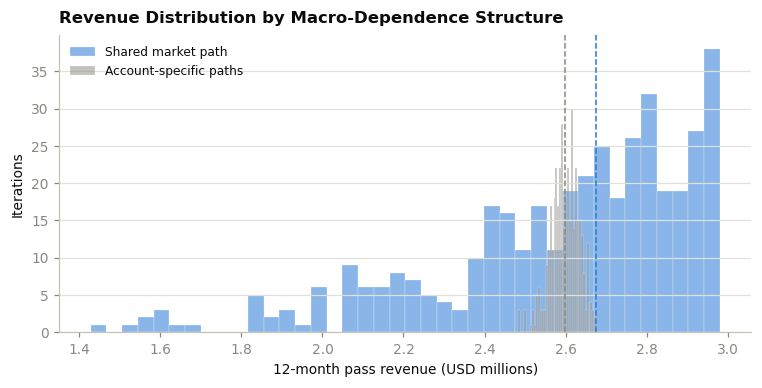

In [33]:
# Test Cross-Account Correlation
ACCOUNT_INDEX = pd.factorize(
    panel['account_id'].to_numpy()
)[0]

N_ACCOUNTS = (
    int(ACCOUNT_INDEX.max())
    + 1
)


def simulate_account_specific(
    mult,
    n_iter = N_ITER,
    rng = None,
):
    """Simulate account-specific macro paths as a comparison case."""
    if rng is None:
        rng = np.random.default_rng(0)

    probabilities = probs_at(mult)
    state_revenue = rev_at(mult)

    cumulative_probability = (
        probabilities.cumsum(axis = 1)
    )

    simulated_revenue = np.zeros(
        n_iter
    )

    for iteration in range(n_iter):
        travel_share_shift = rng.normal(
            0,
            0.03,
        )

        macro_shocks = rng.normal(
            0,
            0.35,
            (N_ACCOUNTS, 12),
        )

        macro_index = np.zeros(
            (N_ACCOUNTS, 12)
        )

        macro_index[:, 0] = (
            0.85 * Z_LAST
            + macro_shocks[:, 0]
        )

        for month_index in range(1, 12):
            macro_index[:, month_index] = (
                0.85
                * macro_index[:, month_index - 1]
                + macro_shocks[:, month_index]
            )

        travel_multiplier = (
            np.exp(
                0.55 * macro_index
            )
            * (1.0 + travel_share_shift)
        )

        occurrence_probability = np.clip(
            (
                travel_multiplier[
                    ACCOUNT_INDEX,
                    MONTH,
                ]
                * SEASON
                / HIST_M
            ),
            0,
            1,
        )

        occurs = (
            rng.random(N)
            < occurrence_probability
        )

        uniform_draw = rng.random(N)

        state = (
            uniform_draw[:, None]
            > cumulative_probability
        ).sum(axis = 1)

        simulated_revenue[iteration] = np.where(
            occurs,
            state_revenue[
                np.arange(N),
                state,
            ],
            0.0,
        ).sum()

    return simulated_revenue


account_specific = simulate_account_specific(
    1.0,
    rng = np.random.default_rng(3),
)

shared_cv = (
    base.std(ddof = 1)
    / base.mean()
)

account_specific_cv = (
    account_specific.std(ddof = 1)
    / account_specific.mean()
)

shared_width = (
    np.percentile(base, 95)
    - np.percentile(base, 5)
)

account_specific_width = (
    np.percentile(
        account_specific,
        95,
    )
    - np.percentile(
        account_specific,
        5,
    )
)

spread_ratio = (
    shared_cv
    / max(
        account_specific_cv,
        1e-9,
    )
)

correlation_summary = pd.DataFrame({
    'Macro Structure': [
        'Shared market path',
        'Account-specific paths',
    ],
    'Mean Revenue': [
        base.mean(),
        account_specific.mean(),
    ],
    'Median Revenue': [
        np.median(base),
        np.median(account_specific),
    ],
    'Coefficient of Variation': [
        shared_cv,
        account_specific_cv,
    ],
    'P5–P95 Width': [
        shared_width,
        account_specific_width,
    ],
})

display(
    correlation_summary.style
    .hide(axis = 'index')
    .format({
        'Mean Revenue': '{:,.0f}',
        'Median Revenue': '{:,.0f}',
        'Coefficient of Variation': '{:.1%}',
        'P5–P95 Width': '{:,.0f}',
    })
    .bar(
        subset = ['Coefficient of Variation'],
        color = 'rgba(42, 120, 214, 0.45)',
        vmin = 0,
        vmax = max(
            shared_cv,
            account_specific_cv,
        )
        * 1.15,
    )
    .set_caption(
        'Revenue Variation Under Alternative Macro Structures (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

spread_summary = pd.DataFrame({
    'Comparison': [
        'Shared vs. account-specific macro paths'
    ],
    'Relative Spread': [
        spread_ratio
    ],
    'Interpretation': [
        (
            'Shared macro conditions produce '
            'the wider portfolio distribution'
        )
    ],
})

display(
    spread_summary.style
    .hide(axis = 'index')
    .format({
        'Relative Spread': '{:.1f}×',
    })
    .set_caption(
        'Effect of Cross-Account Macro Dependence'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Relative Spread'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

fig, ax = plt.subplots(
    figsize = (7, 3.6),
)

ax.hist(
    base / 1e6,
    bins = 40,
    alpha = 0.55,
    color = ACCENT,
    edgecolor = SURFACE,
    linewidth = 0.3,
    label = 'Shared market path',
)

ax.hist(
    account_specific / 1e6,
    bins = 40,
    alpha = 0.50,
    color = MUTED,
    edgecolor = SURFACE,
    linewidth = 0.3,
    label = 'Account-specific paths',
)

ax.axvline(
    np.median(base) / 1e6,
    color = ACCENT,
    linestyle = '--',
    linewidth = 1,
)

ax.axvline(
    np.median(account_specific) / 1e6,
    color = MUTED,
    linestyle = '--',
    linewidth = 1,
)

ax.set(
    xlabel = '12-month pass revenue (USD millions)',
    ylabel = 'Iterations',
)

ax.set_title(
    'Revenue Distribution by Macro-Dependence Structure',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

ax.grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

ax.legend(
    frameon = False,
    fontsize = 8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>3 · The Price Sweep</h2>
<p><strong>Purpose:</strong> Compares simulated 12-month roaming revenue across the candidate-price grid under the base model and a joint stronger-response sensitivity scenario.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Base Model.</strong> Uses the fitted State Model price response and the fitted Magnitude Model reduction depth.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>response_scale = 1.00</code></li>
<li><code>depth_scale = 1.00</code></li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Joint Stronger-Response Sensitivity.</strong> Tests the recommendation under two assumptions that reduce the expected benefit of a price increase.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The State Model price response is multiplied by the regional-holdout sensitivity factor of 1.74.</li>
<li>The predicted shortfall from full coverage is multiplied by the Magnitude Model’s label-contamination factor of 1.04.</li>
<li>The depth factor increases the estimated reduction by 4%; it does not multiply coverage or revenue by 1.04.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">These cases are sensitivity scenarios, not statistical bounds or unbiased corrections.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The regional factor tests whether the fitted price response may be understated when transferred across regions.</li>
<li>The depth factor tests whether reconstructed partial-coverage labels may understate the depth of deliberate reductions.</li>
<li>The joint scenario tests robustness to both assumptions simultaneously; it does not identify how much of the difference is attributable to each assumption separately.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Each scenario is compared with its own standard-price baseline.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The response scale has no effect at the standard price because the Stage 2 price term equals zero.</li>
<li>The depth scale can affect standard-price revenue by changing the revenue assigned to the partial-coverage state.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Common random numbers are used across every candidate price and both scenarios.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each run starts from the same paired stream of macroeconomic, market-share, trip-occurrence, and behavioral draws.</li>
<li>This reduces Monte Carlo variation in comparisons, although it does not eliminate simulation error.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The historically observed prices are 0.90, 0.95, 1.00, 1.10, and 1.20. Other grid points are interpolations shown to trace the shape of the modeled revenue curve; the joint-sensitivity peak at 1.15 falls between the observed 1.10 and 1.20.</li>
<li style="margin-bottom: 0.7em;">The sweep identifies the best price within the tested grid for each case. The as-fitted case rises to the +20% cap; the joint stronger-response sensitivity turns over at 1.15. The recommendation is read from the as-fitted case (Section 5).</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<ol style="margin-top: 0; padding-left: 1.5em;">
  <li>
    In the as-fitted case, median annual roaming revenue rises from approximately
    <span>&#36;</span>2.47 million at x0.90 to <span>&#36;</span>3.00 million
    at x1.20.
  </li>
  <li>
    Relative to the standard-price median of approximately
    <span>&#36;</span>2.67 million, the as-fitted case estimates a gain of
    approximately <span>&#36;</span>324,000 at x1.20.
  </li>
  <li>
    Under the joint stronger-response sensitivity, median annual revenue rises
    from approximately <span>&#36;</span>2.50 million at x0.90 to
    <span>&#36;</span>2.77 million at x1.20.
  </li>
  <li>
    Relative to its standard-price median of approximately
    <span>&#36;</span>2.65 million, the joint sensitivity estimates a gain of
    approximately <span>&#36;</span>143,000 at its x1.15 peak, declining to
    approximately <span>&#36;</span>115,000 at x1.20.
  </li>
  <li>
    At x1.20, the joint sensitivity reduces the estimated gain by approximately
    <span>&#36;</span>209,000 relative to the as-fitted case, while leaving the
    gain positive.
  </li>
  <li>
    Median revenue continues to increase through x1.20 in the as-fitted case.
    Under the joint sensitivity, the curve peaks at x1.15 and then declines.
    The paired-difference test in Section 5 places the x1.15-minus-x1.20
    difference above zero across its 95% interval, indicating that the observed
    turnover is unlikely to be Monte Carlo noise.
  </li>
  <li>
    These results support reading the recommendation from the as-fitted case
    while retaining the joint sensitivity as a robustness check.
  </li>
</ol>
</div>


Case,Price Multiplier,5th Percentile,Median,95th Percentile,Lift vs. Standard
As Fitted,0.900,"1,806,404","2,473,988","2,734,554","-199,760"
As Fitted,0.925,"1,842,652","2,525,768","2,790,653","-147,980"
As Fitted,0.950,"1,880,921","2,576,676","2,846,780","-97,072"
As Fitted,0.975,"1,917,725","2,626,774","2,902,487","-46,973"
As Fitted,1.000,"1,952,039","2,673,748","2,955,430",+0
As Fitted,1.025,"1,976,781","2,709,065","2,993,131","+35,317"
As Fitted,1.050,"2,011,068","2,755,628","3,046,022","+81,880"
As Fitted,1.075,"2,044,882","2,803,119","3,098,219","+129,371"
As Fitted,1.100,"2,078,309","2,849,055","3,150,345","+175,308"
As Fitted,1.125,"2,107,400","2,891,579","3,197,474","+217,832"


Case,Best Evaluated Price,5th Percentile,Median Revenue,95th Percentile,Lift vs. Standard,At Upper Cap
As Fitted,1.200,"2,181,648","2,997,609","3,317,744","+323,862",Yes
Joint Sensitivity,1.150,"2,033,814","2,797,522","3,094,169","+143,237",No


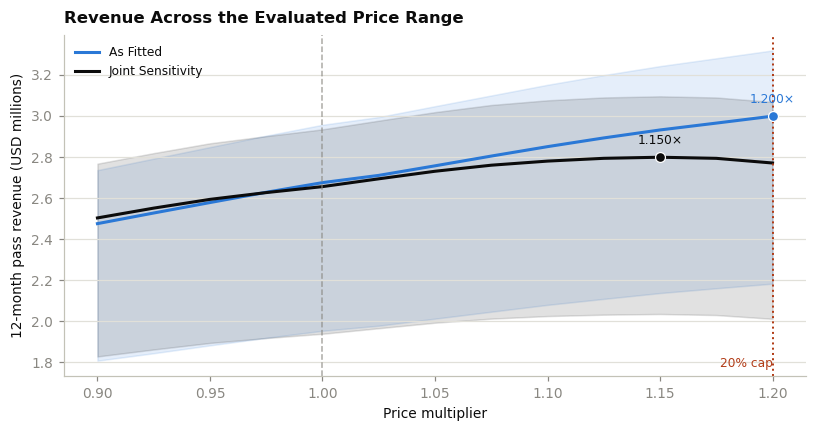

In [34]:
# Sweep Price Range
SWEEP_ITER = 400
CRN_SEED = 4242

case_configurations = [
    {
        'case': 'as fitted',
        'response_scale': 1.0,
        'depth_scale': 1.0,
    },
    {
        'case': 'joint sensitivity',
        'response_scale': RESPONSE_RATIO,
        'depth_scale': DEPTH_BIAS,
    },
]

sweep_rows = []

for multiplier in GRID:
    for configuration in case_configurations:
        simulated, simulated_purchasers = simulate(
            multiplier,
            n_iter = SWEEP_ITER,
            response_scale = configuration[
                'response_scale'
            ],
            depth_scale = configuration[
                'depth_scale'
            ],
            rng = np.random.default_rng(
                CRN_SEED
            ),
            track_purchasers = True,
        )

        sweep_rows.append({
            'price_multiplier': multiplier,
            'case': configuration['case'],
            'p5': np.percentile(
                simulated,
                5,
            ),
            'median': np.median(
                simulated
            ),
            'p95': np.percentile(
                simulated,
                95,
            ),
            'purchasers_p5': np.percentile(
                simulated_purchasers,
                5,
            ),
            'purchasers_median': np.median(
                simulated_purchasers
            ),
            'purchasers_p95': np.percentile(
                simulated_purchasers,
                95,
            ),
        })

sw = pd.DataFrame(sweep_rows)

fitted = (
    sw.loc[
        sw['case'].eq('as fitted')
    ]
    .set_index('price_multiplier')
    .copy()
)

cons = (
    sw.loc[
        sw['case'].eq(
            'joint sensitivity'
        )
    ]
    .set_index('price_multiplier')
    .copy()
)

for scenario_results in [
    fitted,
    cons,
]:
    scenario_results['lift_vs_base'] = (
        scenario_results['median']
        - scenario_results.loc[
            1.0,
            'median',
        ]
    )

    scenario_results['purchasers_lift_vs_base'] = (
        scenario_results['purchasers_median']
        - scenario_results.loc[
            1.0,
            'purchasers_median',
        ]
    )

sw = pd.concat([
    fitted.reset_index().assign(
        case = 'as fitted'
    ),
    cons.reset_index().assign(
        case = 'joint sensitivity'
    ),
], ignore_index = True)

sw['case_display'] = sw['case'].map({
    'as fitted': 'As Fitted',
    'joint sensitivity': 'Joint Sensitivity',
})

sweep_display = (
    sw[[
        'case_display',
        'price_multiplier',
        'p5',
        'median',
        'p95',
        'lift_vs_base',
    ]]
    .rename(columns = {
        'case_display': 'Case',
        'price_multiplier': 'Price Multiplier',
        'p5': '5th Percentile',
        'median': 'Median',
        'p95': '95th Percentile',
        'lift_vs_base': 'Lift vs. Standard',
    })
)

maximum_absolute_lift = max(
    sweep_display[
        'Lift vs. Standard'
    ].abs().max(),
    1,
)

display(
    sweep_display.style
    .hide(axis = 'index')
    .format({
        'Price Multiplier': '{:.3f}',
        '5th Percentile': '{:,.0f}',
        'Median': '{:,.0f}',
        '95th Percentile': '{:,.0f}',
        'Lift vs. Standard': '{:+,.0f}',
    })
    .bar(
        subset = ['Lift vs. Standard'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -maximum_absolute_lift,
        vmax = maximum_absolute_lift,
    )
    .set_caption(
        'Simulated Revenue Across the Price Range (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

scenario_summary_rows = []

for case_name, case_label, results in [
    (
        'as fitted',
        'As Fitted',
        fitted,
    ),
    (
        'joint sensitivity',
        'Joint Sensitivity',
        cons,
    ),
]:
    best_price = float(
        results['median'].idxmax()
    )

    best_result = results.loc[
        best_price
    ]

    scenario_summary_rows.append({
        'Case': case_label,
        'Best Evaluated Price': best_price,
        '5th Percentile': best_result['p5'],
        'Median Revenue': best_result['median'],
        '95th Percentile': best_result['p95'],
        'Lift vs. Standard':
            best_result['lift_vs_base'],
        'At Upper Cap': np.isclose(
            best_price,
            GRID[-1],
        ),
    })

scenario_summary = pd.DataFrame(
    scenario_summary_rows
)

scenario_summary['At Upper Cap'] = (
    scenario_summary['At Upper Cap']
    .map({
        True: 'Yes',
        False: 'No',
    })
)

display(
    scenario_summary.style
    .hide(axis = 'index')
    .format({
        'Best Evaluated Price': '{:.3f}',
        '5th Percentile': '{:,.0f}',
        'Median Revenue': '{:,.0f}',
        '95th Percentile': '{:,.0f}',
        'Lift vs. Standard': '{:+,.0f}',
    })
    .set_caption(
        'Highest-Revenue Evaluated Price by Case (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Best Evaluated Price'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

fig, ax = plt.subplots(
    figsize = (7.5, 4),
)

plot_configurations = [
    (
        fitted,
        'As Fitted',
        ACCENT,
    ),
    (
        cons,
        'Joint Sensitivity',
        INK,
    ),
]

for results, label, color in plot_configurations:
    ax.plot(
        results.index,
        results['median'] / 1e6,
        color = color,
        linewidth = 2,
        label = label,
    )

    ax.fill_between(
        results.index,
        results['p5'] / 1e6,
        results['p95'] / 1e6,
        color = color,
        alpha = 0.12,
    )

    best_price = float(
        results['median'].idxmax()
    )

    best_revenue = (
        results.loc[
            best_price,
            'median',
        ]
        / 1e6
    )

    ax.scatter(
        best_price,
        best_revenue,
        color = color,
        edgecolor = SURFACE,
        linewidth = 0.8,
        s = 42,
        zorder = 4,
    )

    ax.annotate(
        f'{best_price:.3f}×',
        xy = (
            best_price,
            best_revenue,
        ),
        xytext = (0, 9),
        textcoords = 'offset points',
        ha = 'center',
        color = color,
        fontsize = 8,
    )

ax.axvline(
    1.0,
    color = MUTED,
    linestyle = '--',
    linewidth = 1,
    alpha = 0.70,
)

ax.axvline(
    1.20,
    color = '#b23c17',
    linestyle = ':',
    linewidth = 1.3,
)

ax.text(
    1.20,
    0.02,
    '20% cap',
    transform = ax.get_xaxis_transform(),
    ha = 'right',
    va = 'bottom',
    color = '#b23c17',
    fontsize = 8,
)

ax.set(
    xlabel = 'Price multiplier',
    ylabel = '12-month pass revenue (USD millions)',
)

ax.set_title(
    'Revenue Across the Evaluated Price Range',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

ax.grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

ax.legend(
    frameon = False,
    fontsize = 8,
)

plt.tight_layout()
plt.show()


In [35]:
# Sweep Sensitivity Grid
# Independent response-scale x depth-scale grid, full price sweep, Base
# economy only. Purely additive alongside the two-case sweep above — that
# sweep and its exports (sw, sim_out, dim_model_case, fact_portfolio_simulation)
# are untouched; this feeds a separate table for the two-slider sensitivity
# controls (replacing the bundled "Behavior Case" toggle), so nothing that
# already depends on the two-case structure needs to change.
#
# Expansion/Contraction deliberately do NOT cross this grid — they stay fixed
# at RESPONSE_SCALE_GRID[-1] / DEPTH_SCALE_GRID[-1] (today's "joint
# sensitivity" point), exactly as before, to avoid a 3x economy x 3x response
# x 3x depth simulation matrix for a control combination nobody asked for.
sensitivity_rows = []

for response_scale in RESPONSE_SCALE_GRID:
    for depth_scale in DEPTH_SCALE_GRID:
        for multiplier in GRID:
            simulated, simulated_purchasers = simulate(
                multiplier,
                n_iter = SWEEP_ITER,
                response_scale = response_scale,
                depth_scale = depth_scale,
                rng = np.random.default_rng(
                    CRN_SEED
                ),
                track_purchasers = True,
            )

            sensitivity_rows.append({
                'price_multiplier': multiplier,
                'response_scale': response_scale,
                'depth_scale': depth_scale,
                'p5': np.percentile(
                    simulated,
                    5,
                ),
                'median': np.median(
                    simulated
                ),
                'p95': np.percentile(
                    simulated,
                    95,
                ),
                'purchasers_p5': np.percentile(
                    simulated_purchasers,
                    5,
                ),
                'purchasers_median': np.median(
                    simulated_purchasers
                ),
                'purchasers_p95': np.percentile(
                    simulated_purchasers,
                    95,
                ),
            })

sensitivity_grid = pd.DataFrame(sensitivity_rows)

assert (
    sensitivity_grid['p5']
    <= sensitivity_grid['median'] + 1e-6
).all(), 'sensitivity grid: revenue p5 exceeds median'
assert (
    sensitivity_grid['median']
    <= sensitivity_grid['p95'] + 1e-6
).all(), 'sensitivity grid: revenue median exceeds p95'
assert (
    sensitivity_grid['purchasers_p5']
    <= sensitivity_grid['purchasers_median'] + 1e-6
).all(), 'sensitivity grid: purchasers p5 exceeds median'
assert (
    sensitivity_grid['purchasers_median']
    <= sensitivity_grid['purchasers_p95'] + 1e-6
).all(), 'sensitivity grid: purchasers median exceeds p95'
assert (sensitivity_grid['p5'] >= 0).all(), (
    'sensitivity grid: negative revenue'
)
assert (sensitivity_grid['purchasers_p5'] >= 0).all(), (
    'sensitivity grid: negative purchasers'
)

grid_summary = (
    sensitivity_grid
    .loc[
        np.isclose(sensitivity_grid['price_multiplier'], 1.15)
    ]
    .assign(
        response_scale=lambda d: d['response_scale'].round(3),
        depth_scale=lambda d: d['depth_scale'].round(3),
    )
    .pivot(
        index='response_scale',
        columns='depth_scale',
        values='median',
    )
)

display(
    grid_summary.style
    .format('{:,.0f}')
    .set_caption(
        'Median Revenue at 1.15x, by Response/Depth Sensitivity (USD)'
    )
    .set_table_styles(TABLE_STYLES)
)


depth_scale,0.959000,1.000000,1.041000
response_scale,,,
0.243000,"3,015,953","3,009,676","2,999,876"
1.000000,"2,936,910","2,930,364","2,919,634"
1.757000,"2,815,962","2,808,987","2,797,522"


<hr>
<div>
<h2>4 · Macroeconomic Sensitivity Scenarios</h2>
<p style="border-left: 3px solid #b23c17; padding-left: 0.8em; color: #4A4A4A;"><strong>Note:</strong> Section 5 reads the study’s recommendation from the as-fitted model at 1.20, not from the joint stronger-response sensitivity at 1.15. This section is deliberately fixed at 1.15 regardless of that change (it exists to stress-test the joint-sensitivity peak against macro conditions, decoupled from whichever price is the headline recommendation) and is kept as a disclosed robustness/diagnostic reference, not the recommendation basis.</p>
<p><strong>Purpose:</strong> Tests whether the modeled benefit of a 1.15 price increase (the joint stronger-response sensitivity’s peak, evaluated in Section 5 as a robustness check) remains positive under weaker, central, and stronger travel-volume conditions.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">Three macroeconomic conditions are evaluated:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Scenario</th>
<th style="text-align: left;">Macro shift</th>
<th style="text-align: left;">Interpretation</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Contraction</td>
<td style="text-align: left; vertical-align: top;">-0.45</td>
<td style="text-align: left; vertical-align: top;">Lower central travel activity</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Base</td>
<td style="text-align: left; vertical-align: top;">0.00</td>
<td style="text-align: left; vertical-align: top;">Unshifted macroeconomic process</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Expansion</td>
<td style="text-align: left; vertical-align: top;">+0.45</td>
<td style="text-align: left; vertical-align: top;">Higher central travel activity</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;">The shift is applied to the latent macroeconomic index throughout the forward year.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The contraction shift reduces the central travel multiplier by approximately 22%.</li>
<li>The expansion shift increases it by approximately 28%.</li>
<li>These effects are calculated before seasonality, market-share variation, and trip-occurrence limits are applied.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Each scenario retains the same 12-month AR(1) process.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Random macroeconomic variation continues around the shifted central level.</li>
<li>The scenarios therefore represent distributions of possible outcomes under three different macroeconomic conditions, not three deterministic forecasts.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The macroeconomic shift changes trip occurrence only.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>It does not change the State Model’s coverage probabilities.</li>
<li>It does not assume that customers become more or less price-sensitive during a contraction or expansion.</li>
<li>It does not change revenue conditional on a trip and coverage state.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">All scenarios use the joint stronger-response sensitivity from Section 3:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li><code>response_scale = 1.74</code></li>
<li><code>depth_scale = 1.04</code></li>
</ul></li>
<li style="margin-bottom: 0.7em;">The 1.15 and 1.00 prices are compared using common random numbers.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each paired iteration uses the same macroeconomic path, market-share draw, trip-occurrence draws, and behavioral draws.</li>
<li>The resulting revenue difference isolates the modeled effect of changing price within that simulated environment.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The decision is evaluated from the paired revenue difference:
<p><code>revenue at 1.15 − revenue at 1.00</code></p>
<p>For each macroeconomic condition, the study reports its median, 5th and 95th percentiles, and the probability that the difference is negative.</p></li>
<li style="margin-bottom: 0.7em;">These scenarios are sensitivity tests rather than assigned economic forecasts. Results support conclusions only across the three macroeconomic shifts evaluated here.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Scenario</th>
<th style="text-align: left;">Median at 1.00</th>
<th style="text-align: left;">Median at 1.15</th>
<th style="text-align: left;">Difference in medians</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Contraction</td>
<td style="text-align: left; vertical-align: top;">&#36;2.29 million</td>
<td style="text-align: left; vertical-align: top;">&#36;2.41 million</td>
<td style="text-align: left; vertical-align: top;">+&#36;0.12 million</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Base</td>
<td style="text-align: left; vertical-align: top;">&#36;2.64 million</td>
<td style="text-align: left; vertical-align: top;">&#36;2.78 million</td>
<td style="text-align: left; vertical-align: top;">+&#36;0.14 million</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Expansion</td>
<td style="text-align: left; vertical-align: top;">&#36;2.86 million</td>
<td style="text-align: left; vertical-align: top;">&#36;3.01 million</td>
<td style="text-align: left; vertical-align: top;">+&#36;0.15 million</td>
</tr>
</tbody>
</table>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li>The 1.15 price produces a positive difference in medians under all three tested macroeconomic conditions.</li>
<li>The estimated median benefit ranges from approximately &#36;124,000 under contraction to &#36;154,000 under expansion.</li>
<li>The paired revenue-difference results are:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Scenario</th>
<th style="text-align: left;">5th percentile</th>
<th style="text-align: left;">Median</th>
<th style="text-align: left;">95th percentile</th>
<th style="text-align: left;">Probability of a negative difference</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">Contraction</td>
<td style="text-align: left; vertical-align: top;">&#36;86,000</td>
<td style="text-align: left; vertical-align: top;">&#36;124,000</td>
<td style="text-align: left; vertical-align: top;">&#36;154,000</td>
<td style="text-align: left; vertical-align: top;">0.0%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Base</td>
<td style="text-align: left; vertical-align: top;">&#36;108,000</td>
<td style="text-align: left; vertical-align: top;">&#36;144,000</td>
<td style="text-align: left; vertical-align: top;">&#36;163,000</td>
<td style="text-align: left; vertical-align: top;">0.0%</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Expansion</td>
<td style="text-align: left; vertical-align: top;">&#36;129,000</td>
<td style="text-align: left; vertical-align: top;">&#36;154,000</td>
<td style="text-align: left; vertical-align: top;">&#36;165,000</td>
<td style="text-align: left; vertical-align: top;">0.0%</td>
</tr>
</tbody>
</table></li>
<li>The current results show that the positive median effect is not limited to the unshifted macroeconomic process. The paired distributions determine whether that conclusion also holds on a risk-adjusted basis.</li>
<li>These scenarios test sensitivity to travel volume. They do not establish that price sensitivity would remain unchanged under economic conditions outside those modeled.</li>
</ol>
</div>


,1.00×,1.15×,1.20×
Scenario,,,
Contraction,2.29,2.41,2.39
Base,2.64,2.78,2.76
Expansion,2.86,3.01,2.99


Scenario,5th Percentile,Median Gain,95th Percentile,Negative Difference Frequency,Purchasers 5th Percentile,Purchasers Median Change,Purchasers 95th Percentile,Purchasers Negative Frequency
Contraction,"+85,588","+124,149","+154,376",0.0%,-825.000000,-753.000000,-642.750000,1.000000
Base,"+107,817","+143,532","+162,529",0.0%,-845.150000,-787.000000,-705.950000,1.000000
Expansion,"+128,883","+153,890","+165,463",0.0%,-856.050000,-803.000000,-747.950000,1.000000


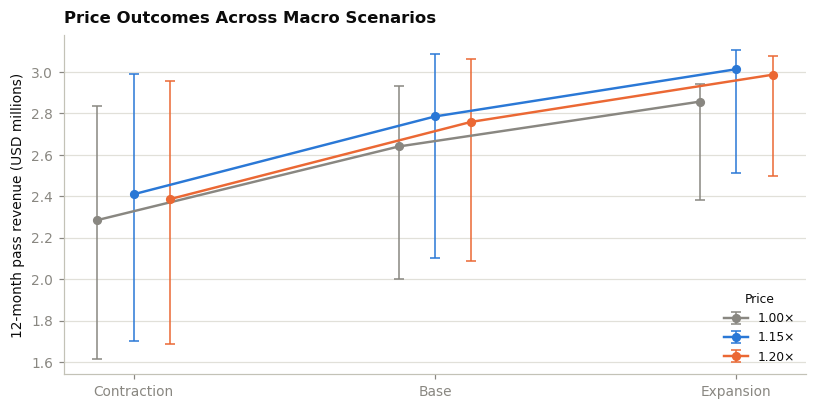

In [36]:
# Test Macro Scenarios
MACRO_SCENARIOS = {
    'Contraction': -0.45,
    'Base': 0.0,
    'Expansion': 0.45,
}

KEY_PRICES = [
    1.00,
    1.15,
    1.20,
]

scenario_rows = []
runs = {}

for scenario, macro_shift in MACRO_SCENARIOS.items():
    for multiplier in KEY_PRICES:
        simulated, simulated_purchasers = simulate(
            multiplier,
            n_iter = 300,
            response_scale = RESPONSE_RATIO,
            depth_scale = DEPTH_BIAS,
            macro_shift = macro_shift,
            rng = np.random.default_rng(
                CRN_SEED
            ),
            track_purchasers = True,
        )

        runs[(scenario, multiplier)] = (
            simulated,
            simulated_purchasers,
        )

        scenario_rows.append({
            'Scenario': scenario,
            'Macro Shift': macro_shift,
            'Price Multiplier': multiplier,
            '5th Percentile': np.percentile(
                simulated,
                5,
            ),
            'Median': np.median(
                simulated
            ),
            '95th Percentile': np.percentile(
                simulated,
                95,
            ),
            'Purchasers 5th Percentile': np.percentile(
                simulated_purchasers,
                5,
            ),
            'Purchasers Median': np.median(
                simulated_purchasers
            ),
            'Purchasers 95th Percentile': np.percentile(
                simulated_purchasers,
                95,
            ),
        })

sc = pd.DataFrame(scenario_rows)

median_revenue = (
    sc
    .pivot(
        index = 'Scenario',
        columns = 'Price Multiplier',
        values = 'Median',
    )
    .reindex(
        MACRO_SCENARIOS.keys()
    )
    / 1e6
)

median_revenue.columns = [
    f'{multiplier:.2f}×'
    for multiplier in median_revenue.columns
]

display(
    median_revenue.style
    .format('{:.2f}')
    .set_caption(
        'Median 12-Month Pass Revenue by Macro Scenario '
        '(USD Millions)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

paired_rows = []

for scenario in MACRO_SCENARIOS:
    revenue_115, purchasers_115 = runs[(scenario, 1.15)]
    revenue_100, purchasers_100 = runs[(scenario, 1.00)]

    paired_difference = (
        revenue_115
        - revenue_100
    )

    paired_purchaser_difference = (
        purchasers_115
        - purchasers_100
    )

    paired_rows.append({
        'Scenario': scenario,
        '5th Percentile': np.percentile(
            paired_difference,
            5,
        ),
        'Median Gain': np.median(
            paired_difference
        ),
        '95th Percentile': np.percentile(
            paired_difference,
            95,
        ),
        'Negative Difference Frequency': (
            paired_difference < 0
        ).mean(),
        'Purchasers 5th Percentile': np.percentile(
            paired_purchaser_difference,
            5,
        ),
        'Purchasers Median Change': np.median(
            paired_purchaser_difference
        ),
        'Purchasers 95th Percentile': np.percentile(
            paired_purchaser_difference,
            95,
        ),
        'Purchasers Negative Frequency': (
            paired_purchaser_difference < 0
        ).mean(),
    })

diff = pd.DataFrame(paired_rows)

maximum_absolute_difference = max(
    diff[[
        '5th Percentile',
        'Median Gain',
        '95th Percentile',
    ]]
    .abs()
    .to_numpy()
    .max(),
    1,
)

display(
    diff.style
    .hide(axis = 'index')
    .format({
        '5th Percentile': '{:+,.0f}',
        'Median Gain': '{:+,.0f}',
        '95th Percentile': '{:+,.0f}',
        'Negative Difference Frequency': '{:.1%}',
    })
    .bar(
        subset = ['Median Gain'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -maximum_absolute_difference,
        vmax = maximum_absolute_difference,
    )
    .set_caption(
        'Paired Revenue Difference: 1.15 vs. 1.00 (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

scenario_order = list(
    MACRO_SCENARIOS.keys()
)

x_positions = np.arange(
    len(scenario_order)
)

price_styles = {
    1.00: {
        'label': '1.00×',
        'color': MUTED,
        'marker': 'o',
    },
    1.15: {
        'label': '1.15×',
        'color': ACCENT,
        'marker': 'o',
    },
    1.20: {
        'label': '1.20×',
        'color': ACCENT2,
        'marker': 'o',
    },
}

offsets = {
    1.00: -0.12,
    1.15: 0.00,
    1.20: 0.12,
}

fig, ax = plt.subplots(
    figsize = (7.5, 3.8),
)

for multiplier in KEY_PRICES:
    price_results = (
        sc.loc[
            sc[
                'Price Multiplier'
            ].eq(multiplier)
        ]
        .set_index('Scenario')
        .reindex(scenario_order)
    )

    median = (
        price_results['Median']
        .to_numpy()
        / 1e6
    )

    lower_error = (
        price_results['Median']
        - price_results['5th Percentile']
    ).to_numpy() / 1e6

    upper_error = (
        price_results['95th Percentile']
        - price_results['Median']
    ).to_numpy() / 1e6

    style = price_styles[multiplier]

    ax.errorbar(
        x_positions
        + offsets[multiplier],
        median,
        yerr = [
            lower_error,
            upper_error,
        ],
        color = style['color'],
        marker = style['marker'],
        markersize = 5,
        linewidth = 1.6,
        elinewidth = 1,
        capsize = 3,
        label = style['label'],
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(scenario_order)

ax.set_ylabel(
    '12-month pass revenue (USD millions)'
)

ax.set_title(
    'Price Outcomes Across Macro Scenarios',
    loc = 'left',
    fontweight = 'bold',
    pad = 8,
)

ax.grid(
    axis = 'y',
    color = GRIDLINE,
    linewidth = 0.8,
)

ax.legend(
    title = 'Price',
    frameon = False,
    fontsize = 8,
    title_fontsize = 8,
)

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>5 · The Recommendation and Its Decision Boundary</h2>
<p><strong>Purpose:</strong> States the recommended price within the evaluated range, quantifies its modeled revenue effect, and defines the limits of that recommendation.</p>
<p><strong>Recommendation:</strong> Within the study’s permitted price range, a <strong>20% increase (1.20)</strong> is the recommended price. It is read directly from the as-fitted models, the study’s expected-case output, with no sensitivity adjustment. Modeled 12-month roaming revenue is still increasing at 1.20, the top of the evaluated range: the study cannot identify an unconstrained revenue-maximizing price within the range it evaluated, so 1.20 is reported as the best evaluated price, not a proven optimum.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The recommendation is read from the as-fitted model rather than from a sensitivity-adjusted case.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>No response-scale or depth-scale adjustment is applied; this is the model’s direct, calibrated output.</li>
<li>As a robustness check (not the basis for the recommendation), the study also asks what price would be best if two specific model diagnostics turned out to indicate real bias: the State Model’s regional holdout, which produced a stronger price response than predicted in a withheld region, and the Magnitude Model’s label-contamination check.</li>
<li>These are deliberately cautious sensitivity assumptions, not statistical corrections or bounds, and are not incorporated into the price selection.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The recommended price is compared with the current standard price of 1.00 using paired simulation iterations.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Each pair uses the same macroeconomic path, market-share draw, trip-occurrence draws, and behavioral draws.</li>
<li>These use fully independent iterations (antithetic pairing off), so mirrored draws are not counted as independent evidence.</li>
<li>The paired-difference statistics below (comparing 1.15 against 1.00 and against the 1.20 cap) test the joint-sensitivity robustness check described above, not the as-fitted recommendation directly: they show how the recommendation would change if that pessimistic scenario is real.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The robustness check is evaluated using:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Median paired revenue difference versus the standard price</li>
<li>5th and 95th percentiles of that paired difference</li>
<li>Observed frequency of a negative paired difference, with a rule-of-three upper bound when none are observed</li>
<li>A paired-difference test of 1.15 against the 1.20 cap, to establish whether the turnover under that pessimistic case is real rather than simulation noise</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The evaluated grid ends at 1.20.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>In the as-fitted case (the case the recommendation is read from), modeled revenue is still increasing at that boundary; the result is not extrapolated beyond it, and an unconstrained optimum above 1.20 is not identified.</li>
<li>Under the joint stronger-response sensitivity, revenue instead peaks at 1.15 and then declines. The paired difference <code>revenue at 1.15 − revenue at 1.20</code> is positive with a 95% interval that excludes zero under that pessimistic case, so the turnover it implies is not a plateau or a sampling artifact.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The recommendation applies only to modeled roaming-pass revenue.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>The State and Magnitude Models include the behavioral revenue effect of reduced coverage.</li>
<li>The study does not model wireless churn, customer-lifetime effects, competitor responses, reputational effects, or implementation costs.</li>
<li>The result should not be interpreted as maximizing total customer value or total company revenue.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">Section 5.1 scales the recommended price’s modeled revenue effect against an independent, real-world travel-volume anchor and a disclosed market-share assumption, to translate the study’s small illustrative sample into a figure comparable with the company-wide revenue target.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations (Joint Stronger-Response Sensitivity Robustness Check):</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">The as-fitted model’s median revenue keeps rising to 1.20, which is why the recommendation is read from that case. Under the joint stronger-response sensitivity it instead peaks at 1.15; the paired <code>1.15 − 1.20</code> difference under that pessimistic case is about &#36;26,000 with a 95% interval of roughly [&#36;17,000, &#36;34,000] and a Monte Carlo standard error near &#36;160, so within that case 1.15 would be the best evaluated price and its lead over the cap holds across the run.</li>
<li style="margin-bottom: 0.7em;">The estimated median 12-month revenue gain at the recommended 1.20, under the as-fitted model the recommendation is read from, is approximately &#36;324,000. For comparison, at 1.15 the estimated median gain is:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Approximately &#36;257,000 under the as-fitted model</li>
<li>Approximately &#36;143,000 under the joint stronger-response sensitivity</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The joint sensitivity reduces the estimated median gain at 1.15 by approximately &#36;113,000 while leaving it clearly positive, the basis for treating 1.15 as resilient under that pessimistic case, even though it is not the price the study recommends.</li>
<li style="margin-bottom: 0.7em;">The paired revenue-difference distribution for 1.15 versus the standard price, under the joint sensitivity:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Measure</th>
<th style="text-align: left;">Result</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;">5th percentile</td>
<td style="text-align: left; vertical-align: top;">&#36;108,000</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Median</td>
<td style="text-align: left; vertical-align: top;">&#36;143,000</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">95th percentile</td>
<td style="text-align: left; vertical-align: top;">&#36;163,000</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Negative differences observed</td>
<td style="text-align: left; vertical-align: top;">0 of 800</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;">Estimated probability of a negative difference</td>
<td style="text-align: left; vertical-align: top;">0.0%</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;">No negative paired differences appeared in 800 independent iterations. That is an observed frequency of 0 out of 800, not proof that the underlying probability is zero.</li>
<li style="margin-bottom: 0.7em;">With zero negatives in 800 independent iterations, the approximate 95% upper confidence bound on the probability of a loss is 0.38% (rule of three). It should be recalculated if the iteration count changes.</li>
<li style="margin-bottom: 0.7em;">The earlier &#36;&#8722;590,352 figure compared fifth-percentile revenue at the increased price with median revenue at 1.00. Because it combined different macroeconomic outcomes, it did not measure the incremental downside caused by the price change and is no longer reported.</li>
<li style="margin-bottom: 0.7em;">Taken together, this robustness check shows that even under a deliberately pessimistic scenario, a price increase remains clearly favorable to the standard price: the disagreement between the as-fitted and joint-sensitivity cases is about how far to raise price (1.20 versus 1.15), not about whether to. The study’s recommendation of 1.20 is read from the as-fitted model; a broader recommendation would require evaluating the excluded customer and business effects.</li>
</ol>
</div>

Measure,Value,Context
Best evaluated price,1.150×,Joint stronger-response sensitivity
Joint-sensitivity median gain,"+143,237",Relative to the standard price
As-fitted gain at the same price,"+256,616",Relative to the standard price
Negative difference frequency,0.0%,Best evaluated price vs. standard price
Independent paired iterations,800,Common random numbers; antithetic pairing disabled


Comparison,Percentile Range,Lower Bound,Median Difference,Upper Bound,Negative Difference Frequency,MC SE of Mean
1.150 vs. 1.00,5th–95th,"+107,545","+142,530","+162,679",0.0%,614
1.150 vs. 1.20,2.5th–97.5th,"+17,172","+26,010","+34,170",0.0%,156


Decision Check,Assessment
Best evaluated price vs. standard,No negative paired differences observed; rule-of-three upper bound 0.4%
Best evaluated price vs. cap,1.150 exceeds the cap throughout the central 95% modeled paired-difference range


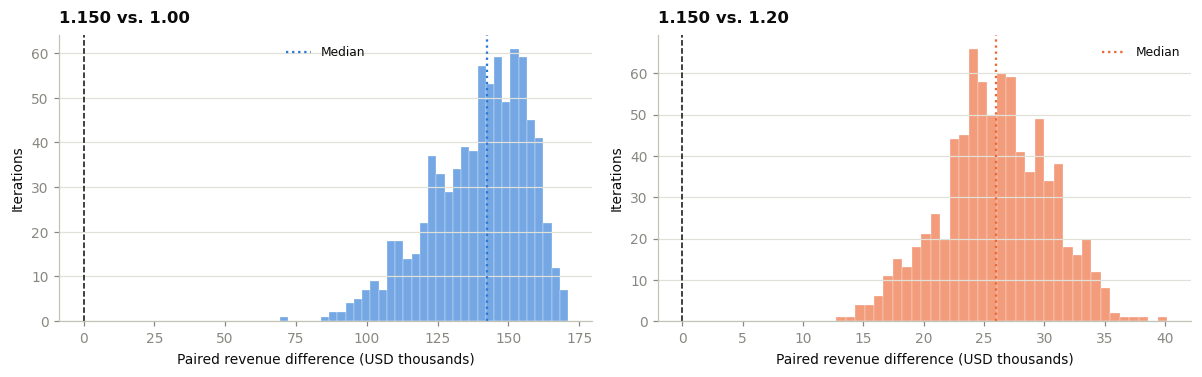

In [37]:
# Build Recommendation
best = float(
    cons['median'].idxmax()
)

cap = float(
    GRID[-1]
)

joint_lift = (
    cons.loc[best, 'median']
    - cons.loc[1.0, 'median']
)

fitted_lift_at_best = (
    fitted.loc[best, 'median']
    - fitted.loc[1.0, 'median']
)

N_PAIRED = 800


def paired_difference(
    higher_price,
    lower_price,
    seed,
):
    higher_revenue = simulate(
        higher_price,
        n_iter = N_PAIRED,
        response_scale = RESPONSE_RATIO,
        depth_scale = DEPTH_BIAS,
        rng = np.random.default_rng(seed),
        antithetic = False,
    )

    lower_revenue = simulate(
        lower_price,
        n_iter = N_PAIRED,
        response_scale = RESPONSE_RATIO,
        depth_scale = DEPTH_BIAS,
        rng = np.random.default_rng(seed),
        antithetic = False,
    )

    return (
        higher_revenue
        - lower_revenue
    )


difference_vs_standard = paired_difference(
    best,
    1.0,
    seed = 99,
)

negative_vs_standard = int(
    (
        difference_vs_standard < 0
    ).sum()
)

negative_frequency = (
    negative_vs_standard
    / N_PAIRED
)

rule_of_three_bound = (
    3 / N_PAIRED
    if negative_vs_standard ==  0
    else np.nan
)

standard_p5, standard_median, standard_p95 = (
    np.percentile(
        difference_vs_standard,
        [5, 50, 95],
    )
)

at_upper_cap = np.isclose(
    best,
    cap,
)

if at_upper_cap:
    difference_vs_cap = None

    cap_assessment = (
        'Revenue is still increasing at the evaluated ceiling; '
        'an unconstrained best price is not identified'
    )
else:
    difference_vs_cap = paired_difference(
        best,
        cap,
        seed = 123,
    )

    cap_lower, cap_median, cap_upper = (
        np.percentile(
            difference_vs_cap,
            [2.5, 50, 97.5],
        )
    )

    cap_negative_frequency = (
        difference_vs_cap < 0
    ).mean()

    cap_mean_se = (
        difference_vs_cap.std(ddof = 1)
        / np.sqrt(N_PAIRED)
    )

    if cap_lower > 0:
        cap_assessment = (
            f'{best:.3f} exceeds the cap throughout the '
            'central 95% modeled paired-difference range'
        )
    elif cap_upper < 0:
        cap_assessment = (
            f'The {cap:.2f} cap exceeds {best:.3f} throughout '
            'the central 95% modeled paired-difference range'
        )
    else:
        cap_assessment = (
            f'The modeled paired-difference range crosses zero; '
            f'{best:.3f} and {cap:.2f} are not consistently ordered'
        )

recommendation_summary = pd.DataFrame({
    'Measure': [
        'Best evaluated price',
        'Joint-sensitivity median gain',
        'As-fitted gain at the same price',
        'Negative difference frequency',
        'Independent paired iterations',
    ],
    'Value': [
        f'{best:.3f}×',
        f'{joint_lift:+,.0f}',
        f'{fitted_lift_at_best:+,.0f}',
        f'{negative_frequency:.1%}',
        f'{N_PAIRED:,}',
    ],
    'Context': [
        'Joint stronger-response sensitivity',
        'Relative to the standard price',
        'Relative to the standard price',
        'Best evaluated price vs. standard price',
        'Common random numbers; antithetic pairing disabled',
    ],
})

display(
    recommendation_summary.style
    .hide(axis = 'index')
    .set_caption('Pricing Recommendation Summary (USD)')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

comparison_rows = [{
    'Comparison': (
        f'{best:.3f} vs. 1.00'
    ),
    'Percentile Range': '5th–95th',
    'Lower Bound': standard_p5,
    'Median Difference': standard_median,
    'Upper Bound': standard_p95,
    'Negative Difference Frequency':
        negative_frequency,
    'MC SE of Mean': (
        difference_vs_standard.std(ddof = 1)
        / np.sqrt(N_PAIRED)
    ),
}]

if difference_vs_cap is not None:
    comparison_rows.append({
        'Comparison': (
            f'{best:.3f} vs. {cap:.2f}'
        ),
        'Percentile Range': '2.5th–97.5th',
        'Lower Bound': cap_lower,
        'Median Difference': cap_median,
        'Upper Bound': cap_upper,
        'Negative Difference Frequency':
            cap_negative_frequency,
        'MC SE of Mean': cap_mean_se,
    })

paired_summary = pd.DataFrame(
    comparison_rows
)

maximum_difference = max(
    paired_summary[[
        'Lower Bound',
        'Median Difference',
        'Upper Bound',
    ]]
    .abs()
    .to_numpy()
    .max(),
    1,
)

display(
    paired_summary.style
    .hide(axis = 'index')
    .format({
        'Lower Bound': '{:+,.0f}',
        'Median Difference': '{:+,.0f}',
        'Upper Bound': '{:+,.0f}',
        'Negative Difference Frequency': '{:.1%}',
        'MC SE of Mean': '{:,.0f}',
    })
    .bar(
        subset = ['Median Difference'],
        align = 'mid',
        color = [
            'rgba(227, 73, 72, 0.45)',
            'rgba(42, 120, 214, 0.45)',
        ],
        vmin = -maximum_difference,
        vmax = maximum_difference,
    )
    .set_caption(
        'Independent Paired-Revenue Comparisons (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

decision_summary = pd.DataFrame({
    'Decision Check': [
        'Best evaluated price vs. standard',
        'Best evaluated price vs. cap',
    ],
    'Assessment': [
        (
            'No negative paired differences observed; '
            f'rule-of-three upper bound '
            f'{rule_of_three_bound:.1%}'
            if negative_vs_standard ==  0
            else (
                f'{negative_frequency:.1%} of paired '
                'differences are negative'
            )
        ),
        cap_assessment,
    ],
})

display(
    decision_summary.style
    .hide(axis = 'index')
    .set_caption('Recommendation Checks')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

plot_series = [
    (
        difference_vs_standard,
        f'{best:.3f} vs. 1.00',
        ACCENT,
    )
]

if difference_vs_cap is not None:
    plot_series.append((
        difference_vs_cap,
        f'{best:.3f} vs. {cap:.2f}',
        ACCENT2,
    ))

fig, axes = plt.subplots(
    1,
    len(plot_series),
    figsize = (
        7.5 if len(plot_series) ==  1 else 11,
        3.5,
    ),
    squeeze = False,
)

for ax, (
    differences,
    comparison_label,
    color,
) in zip(
    axes.ravel(),
    plot_series,
):
    ax.hist(
        differences / 1e3,
        bins = 35,
        color = color,
        alpha = 0.65,
        edgecolor = SURFACE,
        linewidth = 0.3,
    )

    ax.axvline(
        0,
        color = INK,
        linestyle = '--',
        linewidth = 1,
    )

    ax.axvline(
        np.median(differences) / 1e3,
        color = color,
        linestyle = ':',
        linewidth = 1.5,
        label = 'Median',
    )

    ax.set(
        xlabel = 'Paired revenue difference (USD thousands)',
        ylabel = 'Iterations',
    )

    ax.set_title(
        comparison_label,
        loc = 'left',
        fontweight = 'bold',
        pad = 8,
    )

    ax.grid(
        axis = 'y',
        color = GRIDLINE,
        linewidth = 0.8,
    )

    ax.legend(
        frameon = False,
        fontsize = 8,
    )

plt.tight_layout()
plt.show()


<hr>
<div>
<h2>5.1 · Market Sizing from Independent Travel Data</h2>
<p><strong>Purpose:</strong> Scales the recommended price's modeled revenue effect from the study's small illustrative synthetic book to a figure comparable with the &#36;100 million company-wide target, using an independent real-world travel-volume anchor rather than any number internal to the synthetic data.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;"><strong>Real-world anchor.</strong> The U.S. Department of Commerce's I-92 program publishes monthly U.S. citizen international air-travel counts. The most recent complete year is used; 2020, 2021 (pandemic-distorted) and the current partial year are excluded, matching the convention already used for seasonality in the data-generation notebook.</li>
<li style="margin-bottom: 0.7em;"><strong>Trips, not accounts.</strong> I-92 counts individual trips. The simulation's natural per-unit basis is therefore modeled revenue per forward-year trip template (<code>N</code>, 52,500 templates) rather than revenue per eligible account: an account can carry multiple lines and multiple trips in a year, so scaling by account count alone would conflate those into an inflated per-unit figure. Dividing by trip templates instead keeps the scale-up on the same footing as the I-92 counts, with no separate trips-per-traveler conversion required.</li>
<li style="margin-bottom: 0.7em;"><strong>Market share.</strong> A 30% assumed share of national international-travel trips for this carrier is applied. This is a disclosed assumption, not a figure derived from the data, and is the main lever an analyst would revisit if a different carrier scale is more appropriate.</li>
<li style="margin-bottom: 0.7em;"><strong>Consistent case.</strong> The scale-up uses the as-fitted revenue curve, the case the recommendation is read from (Section 5), so the market-sized figure and the headline recommendation are read from the same model output.</li>
<li style="margin-bottom: 0.7em;">This calculation is illustrative, consistent with the synthetic nature of the underlying study; it demonstrates the scaling methodology rather than reporting the real engagement's actual market size.</li>
</ol>
</div>

In [38]:
# Market Sizing from Independent Travel Data
I92 = pd.read_csv('data/reference/us_i92_air_travel.csv')

# Exclude pandemic-distorted years and the partial current year, matching
# the convention used for seasonality in the data-generation notebook.
i92_annual = (
    I92.loc[~I92['Year'].isin([2020, 2021, 2026])]
    .groupby('Year')['U.S. Citizen Originating']
    .sum()
)

I92_YEAR = int(i92_annual.index.max())
I92_TRIPS = float(i92_annual.loc[I92_YEAR])

MARKET_SHARE = 0.30

national_trips = I92_TRIPS * MARKET_SHARE

revenue_per_trip = fitted['median'] / N
base_revenue_per_trip = float(revenue_per_trip.loc[1.0])

market_sizing_rows = []
for price in GRID:  # full 13-point grid, so every slider position has a scaled figure
    rpt = float(revenue_per_trip.loc[price])
    scaled_revenue = rpt * national_trips
    scaled_lift = (rpt - base_revenue_per_trip) * national_trips
    market_sizing_rows.append({
        'Price Multiplier': price,
        'Revenue per Trip (As Fitted)': rpt,
        'Scaled Annual Revenue': scaled_revenue,
        'Scaled Lift vs. Standard': scaled_lift,
        'Share of $100M Target': scaled_lift / 100_000_000,
    })

market_sizing = pd.DataFrame(market_sizing_rows)

display(
    market_sizing.style
    .hide(axis = 'index')
    .format({
        'Price Multiplier': '{:.2f}×',
        'Revenue per Trip (As Fitted)': '${:,.2f}',
        'Scaled Annual Revenue': '${:,.0f}',
        'Scaled Lift vs. Standard': '{:+,.0f}',
        'Share of $100M Target': '{:.1%}',
    })
    .set_caption(
        f'Market-Sized Revenue Impact — {I92_YEAR} I-92 Trips × '
        f'{MARKET_SHARE:.0%} Assumed Share (USD)'
    )
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)

# Read the as-fitted optimum directly (RECOMMENDED_PRICE isn't in scope until
# Model 04) rather than hardcoding 1.20, so this stays correct if the sweep changes.
recommended_price_here = float(fitted['median'].idxmax())
recommended_row = market_sizing.loc[
    np.isclose(market_sizing['Price Multiplier'], recommended_price_here)
].iloc[0]

print(
    f"{I92_YEAR} I-92 U.S. citizen originating trips: {I92_TRIPS:,.0f}\n"
    f"Assumed carrier market share: {MARKET_SHARE:.0%}  ->  "
    f"national addressable trips: {national_trips:,.0f}\n"
    f"Recommended price ({recommended_price_here:.2f}x) scaled lift: "
    f"${recommended_row['Scaled Lift vs. Standard']:,.0f} "
    f"({recommended_row['Share of $100M Target']:.1%} of the $100M target)"
)

save_tables({'market_sizing': market_sizing})

Price Multiplier,Revenue per Trip (As Fitted),Scaled Annual Revenue,Scaled Lift vs. Standard,Share of $100M Target
0.90×,$47.12,"$794,329,542","-64,137,458",-64.1%
0.93×,$48.11,"$810,954,841","-47,512,159",-47.5%
0.95×,$49.08,"$827,299,843","-31,167,157",-31.2%
0.97×,$50.03,"$843,385,198","-15,081,802",-15.1%
1.00×,$50.93,"$858,467,000",+0,0.0%
1.02×,$51.60,"$869,806,401","+11,339,400",11.3%
1.05×,$52.49,"$884,756,543","+26,289,543",26.3%
1.07×,$53.39,"$900,004,621","+41,537,621",41.5%
1.10×,$54.27,"$914,753,431","+56,286,431",56.3%
1.12×,$55.08,"$928,406,742","+69,939,741",69.9%


2025 I-92 U.S. citizen originating trips: 56,187,701
Assumed carrier market share: 30%  ->  national addressable trips: 16,856,310
Recommended price (1.20x) scaled lift: $103,983,046 (104.0% of the $100M target)


,rows
market_sizing.parquet,13


<hr>
<div>
<h2>6 · Simulation Outputs and Downstream Handoff</h2>
<p><strong>Purpose:</strong> Publishes the price-sweep results, macroeconomic sensitivity results, and simulation assumptions used by the segmentation and the Power BI scenario model.</p>
<p style="margin-bottom: 0;"><strong>Design Notes:</strong></p>
<ol style="margin-top: 0; margin-left: 0; padding-left: 1.25em;">
<li style="margin-bottom: 0.7em;">Three artifacts provide the downstream simulation results and their supporting assumptions:
<table style="width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Artifact</th>
<th style="text-align: left;">Grain</th>
<th style="text-align: left;">Purpose</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_price_sweep</code></td>
<td style="text-align: left; vertical-align: top;">One row per candidate price and model-sensitivity scenario</td>
<td style="text-align: left; vertical-align: top;">Stores the simulated annual revenue distribution across the complete price grid</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_scenarios</code></td>
<td style="text-align: left; vertical-align: top;">One row per macroeconomic condition and evaluated price</td>
<td style="text-align: left; vertical-align: top;">Stores absolute revenue outcomes and paired differences from the standard price under the joint sensitivity</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_assumptions</code></td>
<td style="text-align: left; vertical-align: top;">One row per named simulation input or setting</td>
<td style="text-align: left; vertical-align: top;">Documents the parameters required to interpret and reproduce the simulation</td>
</tr>
</tbody>
</table></li>
<li style="margin-bottom: 0.7em;"><strong>Price-Sweep Output.</strong> <code>simulation_price_sweep</code> includes:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Candidate <code>price_multiplier</code></li>
<li>Percentage change from the standard price</li>
<li>Base or joint-sensitivity scenario</li>
<li>5th-percentile annual roaming revenue</li>
<li>Median annual roaming revenue</li>
<li>95th-percentile annual roaming revenue</li>
<li>An indicator flagging the five historically observed price points (every grid price lies inside the observed range, so nothing on the grid is extrapolated)</li>
<li>Simulation-run identifier</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Macroeconomic-Scenario Output.</strong> <code>simulation_scenarios</code> includes:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Contraction, base, or expansion condition</li>
<li>Macro shift</li>
<li>Evaluated price</li>
<li>5th-percentile, median, and 95th-percentile annual roaming revenue</li>
<li>5th-percentile, median, and 95th-percentile paired revenue difference from the standard price</li>
<li>Observed frequency of a negative paired difference</li>
<li>Number of paired simulation iterations</li>
<li>Simulation-run identifier</li>
</ul></li>
<li style="margin-bottom: 0.7em;"><strong>Assumptions Output.</strong> <code>simulation_assumptions</code> records:
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>Standard price and candidate-price grid</li>
<li>Observed and extrapolated price ranges</li>
<li>AR(1) persistence and shock scale</li>
<li>Macroeconomic response parameter</li>
<li>Contraction and expansion shifts</li>
<li>Market-share shock scale</li>
<li>Base and joint-sensitivity response scales</li>
<li>Base and joint-sensitivity depth scales</li>
<li>Iteration count</li>
<li>Random seed</li>
<li>Class order</li>
<li>Synthetic-data completeness assumption</li>
<li>Model and simulation-run identifiers</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The regional response factor and label-contamination factor are identified as <strong>sensitivity assumptions informed by model diagnostics</strong>.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>They are not described as unbiased corrections or statistical bounds.</li>
<li><code>response scale (joint sensitivity)</code> replaces <code>response scale (conservative)</code>.</li>
<li><code>depth scale (joint sensitivity)</code> replaces <code>depth bias (conservative)</code>.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">The observed probability of a negative paired difference is stored with the simulation results rather than the assumptions.
<ul style="margin: 0.15em 0 0; padding-left: 1.25em;">
<li>It is reported as an observed frequency with its iteration count.</li>
<li>When no negative differences are observed, a confidence bound is included rather than interpreting the probability as exactly zero.</li>
</ul></li>
<li style="margin-bottom: 0.7em;">All monetary values represent modeled roaming-pass revenue only. The exports do not incorporate wireless churn, customer-lifetime effects, competitor responses, reputational effects, or implementation costs.</li>
<li style="margin-bottom: 0.7em;"><code>save_tables</code> writes the three tables and reports their row counts (7 assumption rows: two sensitivity scales, sweep and macro iteration counts, paired-iteration count, seed, and run id). Column-level and read-back validation are not performed in code.</li>
</ol>
<p style="margin-bottom: 0;"><strong>Observations:</strong></p>
<table style="margin-top: 0; width: 100%; border-collapse: collapse;">
<thead>
<tr>
<th style="text-align: left;">Artifact</th>
<th style="text-align: left;">Rows</th>
<th style="text-align: left;">Format</th>
</tr>
</thead>
<tbody>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_price_sweep.parquet</code></td>
<td style="text-align: left; vertical-align: top;">26</td>
<td style="text-align: left; vertical-align: top;">Parquet</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_scenarios.parquet</code></td>
<td style="text-align: left; vertical-align: top;">9</td>
<td style="text-align: left; vertical-align: top;">Parquet</td>
</tr>
<tr>
<td style="text-align: left; vertical-align: top;"><code>simulation_assumptions.parquet</code></td>
<td style="text-align: left; vertical-align: top;">7</td>
<td style="text-align: left; vertical-align: top;">Parquet</td>
</tr>
</tbody>
</table>
<ol style="margin-left: 0; padding-left: 1.25em;">
<li>The price-sweep output contains 13 candidate prices under the as-fitted and joint stronger-response sensitivity scenarios (26 rows).</li>
<li>The macroeconomic output contains three prices (1.00, 1.15, 1.20) under contraction, base, and expansion conditions (9 rows).</li>
<li>Simulation settings and sensitivity assumptions travel with the results so Notebook 04 and Power BI do not depend on undocumented constants.</li>
<li>The paired downside measures are stored with the scenario results and remain distinguishable from simulation inputs.</li>
<li>All exports use the same simulation-run identifier so downstream outputs can be traced to one consistent execution.</li>
</ol>
</div>


In [39]:
# Export Simulation Results
MACRO_ITER = 300

RUN_ID = (
    f'sim-crn{CRN_SEED}'
    f'-sweep{SWEEP_ITER}'
    f'-macro{MACRO_ITER}'
    f'-paired{N_PAIRED}'
)

sim_out = (
    sw[[
        'price_multiplier',
        'case',
        'p5',
        'median',
        'p95',
        'lift_vs_base',
        'purchasers_p5',
        'purchasers_median',
        'purchasers_p95',
        'purchasers_lift_vs_base',
    ]]
    .copy()
)

sim_out['eligible_accounts'] = N_ACCOUNTS_PANEL

sim_out['price_change_pct'] = (
    sim_out['price_multiplier']
    - 1
) * 100

observed_prices = np.array([
    0.90,
    0.95,
    1.00,
    1.10,
    1.20,
])

# Flags the five historically observed price points. Every grid point (0.90-1.20)
# lies inside the observed range, so a range test would be true everywhere and
# carry no information; the useful distinction is observed point vs. interpolated.
sim_out['observed_price_point'] = sim_out[
    'price_multiplier'
].map(
    lambda price: np.isclose(
        price,
        observed_prices,
    ).any()
)

recommendation_row = (
    sim_out['case'].eq(
        'joint sensitivity'
    )
    & np.isclose(
        sim_out['price_multiplier'],
        best,
    )
)

sim_out['neg_paired_freq'] = np.where(
    recommendation_row,
    negative_frequency,
    np.nan,
)

sim_out['neg_paired_iters'] = np.where(
    recommendation_row,
    N_PAIRED,
    np.nan,
)

sim_out['run_id'] = RUN_ID

scenario_results = (
    sc
    .rename(columns = {
        'Scenario': 'scenario',
        'Macro Shift': 'macro_shift',
        'Price Multiplier': 'price',
        '5th Percentile': 'p5',
        'Median': 'median',
        '95th Percentile': 'p95',
        'Purchasers 5th Percentile': 'purchasers_p5',
        'Purchasers Median': 'purchasers_median',
        'Purchasers 95th Percentile': 'purchasers_p95',
    })
    .copy()
)

scenario_results['eligible_accounts'] = N_ACCOUNTS_PANEL

paired_macro_results = (
    diff
    .rename(columns = {
        'Scenario': 'scenario',
        '5th Percentile': 'paired_p5',
        'Median Gain': 'paired_median',
        '95th Percentile': 'paired_p95',
        'Negative Difference Frequency':
            'paired_neg_freq',
        'Purchasers 5th Percentile':
            'purchasers_paired_p5',
        'Purchasers Median Change':
            'purchasers_paired_median',
        'Purchasers 95th Percentile':
            'purchasers_paired_p95',
        'Purchasers Negative Frequency':
            'purchasers_paired_neg_freq',
    })
)

scen_out = scenario_results.merge(
    paired_macro_results,
    on = 'scenario',
    how = 'left',
)

paired_price_row = np.isclose(
    scen_out['price'],
    1.15,
)

paired_columns = [
    'paired_p5',
    'paired_median',
    'paired_p95',
    'paired_neg_freq',
    'purchasers_paired_p5',
    'purchasers_paired_median',
    'purchasers_paired_p95',
    'purchasers_paired_neg_freq',
]

scen_out.loc[
    ~paired_price_row,
    paired_columns,
] = np.nan

scen_out['price_change_pct'] = (
    scen_out['price']
    - 1
) * 100

scen_out['paired_iters'] = np.where(
    paired_price_row,
    MACRO_ITER,
    np.nan,
)

scen_out['run_id'] = RUN_ID

assumptions = pd.DataFrame({
    'assumption': [
        'response scale (joint sensitivity)',
        'depth scale (joint sensitivity)',
        'sweep iterations per price',
        'macro iterations per scenario',
        'independent paired iterations',
        'common random-number seed',
        'simulation run id',
    ],
    'value': [
        f'{RESPONSE_RATIO:.4f}',
        f'{DEPTH_BIAS:.4f}',
        str(SWEEP_ITER),
        str(MACRO_ITER),
        str(N_PAIRED),
        str(CRN_SEED),
        RUN_ID,
    ],
    'note': [
        (
            'sensitivity assumption informed by the '
            'State Model regional holdout'
        ),
        (
            'sensitivity assumption informed by the '
            'Magnitude Model label-contamination check'
        ),
        'used for each price and response case',
        'used for each price and macro scenario',
        (
            'antithetic pairing disabled for '
            'recommendation comparisons'
        ),
        'shared across prices within each comparison',
        'shared by all simulation export tables',
    ],
})

assumptions_display = (
    assumptions
    .rename(columns = {
        'assumption': 'Assumption',
        'value': 'Value',
        'note': 'Note',
    })
)

display(
    assumptions_display.style
    .hide(axis = 'index')
    .set_caption('Simulation Configuration')
    .set_properties(**{'text-align': 'left'})
    .set_properties(
        subset = ['Value'],
        **{
            'color': ACCENT,
            'font-weight': 'bold',
        },
    )
    .set_table_styles(TABLE_STYLES)
)

assert sim_out['run_id'].eq(
    RUN_ID
).all(), 'inconsistent run ID in price-sweep output'

assert scen_out['run_id'].eq(
    RUN_ID
).all(), 'inconsistent run ID in scenario output'

assert (
    sim_out.loc[
        ~recommendation_row,
        'neg_paired_freq',
    ]
    .isna()
    .all()
), 'paired frequency attached to an incorrect price row'

assert (
    scen_out.loc[
        ~paired_price_row,
        paired_columns,
    ]
    .isna()
    .all()
    .all()
), 'macro paired results attached to an incorrect price row'

assert (sim_out['purchasers_p5'] <= sim_out['purchasers_median'] + 1e-6).all(), (
    'purchasers p5 exceeds median in the price sweep'
)
assert (sim_out['purchasers_median'] <= sim_out['purchasers_p95'] + 1e-6).all(), (
    'purchasers median exceeds p95 in the price sweep'
)
assert (sim_out['purchasers_p95'] <= sim_out['eligible_accounts'] + 1e-6).all(), (
    'purchasers p95 exceeds the eligible-account population in the price sweep'
)
assert (sim_out['purchasers_p5'] >= 0).all(), (
    'negative purchasers in the price sweep'
)

assert (scen_out['purchasers_p5'] <= scen_out['purchasers_median'] + 1e-6).all(), (
    'purchasers p5 exceeds median in the macro scenarios'
)
assert (scen_out['purchasers_median'] <= scen_out['purchasers_p95'] + 1e-6).all(), (
    'purchasers median exceeds p95 in the macro scenarios'
)
assert (scen_out['purchasers_p95'] <= scen_out['eligible_accounts'] + 1e-6).all(), (
    'purchasers p95 exceeds the eligible-account population in the macro scenarios'
)
assert (scen_out['purchasers_p5'] >= 0).all(), (
    'negative purchasers in the macro scenarios'
)

export_summary = save_tables(
    {
        'simulation_price_sweep': sim_out,
        'simulation_scenarios': scen_out,
        'simulation_assumptions': assumptions,
        'probability_curve': probability_curve,
        'sensitivity_grid': sensitivity_grid,
    },
    with_cols = True,
)

export_summary = (
    export_summary
    .rename_axis('File')
    .reset_index()
    .rename(columns = {
        'rows': 'Rows',
        'cols': 'Columns',
    })
)

display(
    export_summary.style
    .hide(axis = 'index')
    .format({
        'Rows': '{:,.0f}',
        'Columns': '{:,.0f}',
    })
    .set_caption('Exported Simulation Tables')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles(TABLE_STYLES)
)


Assumption,Value,Note
response scale (joint sensitivity),1.7567,sensitivity assumption informed by the State Model regional holdout
depth scale (joint sensitivity),1.0408,sensitivity assumption informed by the Magnitude Model label-contamination check
sweep iterations per price,400,used for each price and response case
macro iterations per scenario,300,used for each price and macro scenario
independent paired iterations,800,antithetic pairing disabled for recommendation comparisons
common random-number seed,4242,shared across prices within each comparison
simulation run id,sim-crn4242-sweep400-macro300-paired800,shared by all simulation export tables


File,Rows,Columns
simulation_price_sweep.parquet,26,16
simulation_scenarios.parquet,9,21
simulation_assumptions.parquet,7,3
probability_curve.parquet,39,5
sensitivity_grid.parquet,117,9
